# Classification Only Model

## Import Necessary Libraries

In [1]:
import sys
sys.path.append('../src')
sys.path.append('../src/models')

import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from classification import (
    ClassificationModel,
    TabularDataset,
    train,
    evaluate_binary,
    evaluate_multiclass,
    EarlyStopping
)

## Set Random Seed, For Reproducibility

In [2]:
# For reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load Dataset

In [3]:
mwr_df_simple = pd.read_csv('mwr_simple.csv')

## Extract Features

In [24]:
# Select feature columns (sensor readings)
feature_cols = [col for col in mwr_df_simple.columns if col.endswith('int') or col.endswith('sk')]
mwr_df_simple['features'] = mwr_df_simple[feature_cols].values.tolist()

# Prepare labels and text targets
mwr_df_simple['class_label'] = mwr_df_simple['y_binary'].astype(int)

## Split Data into Test and Train

In [25]:
train_simple_df, temp_simple_df = train_test_split(
    mwr_df_simple, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df_simple['r:Th']
)

val_simple_df, test_simple_df = train_test_split(
    temp_simple_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_simple_df['r:Th']
)

In [26]:
train_dataset = TabularDataset(train_simple_df)
val_dataset = TabularDataset(val_simple_df)
test_dataset = TabularDataset(test_simple_df)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Initialise Model

In [27]:
model = ClassificationModel(num_features=44, num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

## Train Model - Binary (50 epochs)

In [8]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
f1_scores = []
sensitivities = []
specificities = []
auc_scores = []

epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, f1, sensitivity, specificity, auc = evaluate_binary(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    auc_scores.append(auc)

    print(
        f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f} | "
        f"AUC-ROC: {auc:.4f}" if auc is not None else "AUC-ROC: N/A"
    )

Epoch 01 | Train Loss: 0.7068 | Val Loss: 0.5169 | Train Acc: 0.6200 | Val Acc: 0.7598 | F1: 0.6895 | Sensitivity: 0.9728 | Specificity: 0.0901 | AUC-ROC: 0.6787
Epoch 02 | Train Loss: 0.5478 | Val Loss: 0.5109 | Train Acc: 0.7387 | Val Acc: 0.7587 | F1: 0.7342 | Sensitivity: 0.9079 | Specificity: 0.2896 | AUC-ROC: 0.7142
Epoch 03 | Train Loss: 0.5342 | Val Loss: 0.5050 | Train Acc: 0.7493 | Val Acc: 0.7590 | F1: 0.7451 | Sensitivity: 0.8843 | Specificity: 0.3649 | AUC-ROC: 0.7370
Epoch 04 | Train Loss: 0.5199 | Val Loss: 0.5039 | Train Acc: 0.7531 | Val Acc: 0.7538 | F1: 0.7465 | Sensitivity: 0.8622 | Specificity: 0.4128 | AUC-ROC: 0.7546
Epoch 05 | Train Loss: 0.5151 | Val Loss: 0.5003 | Train Acc: 0.7592 | Val Acc: 0.7563 | F1: 0.7565 | Sensitivity: 0.8383 | Specificity: 0.4983 | AUC-ROC: 0.7666
Epoch 06 | Train Loss: 0.5014 | Val Loss: 0.4994 | Train Acc: 0.7620 | Val Acc: 0.7546 | F1: 0.7568 | Sensitivity: 0.8296 | Specificity: 0.5188 | AUC-ROC: 0.7730
Epoch 07 | Train Loss: 0.500

## Plot Results - Binary (50 epochs)

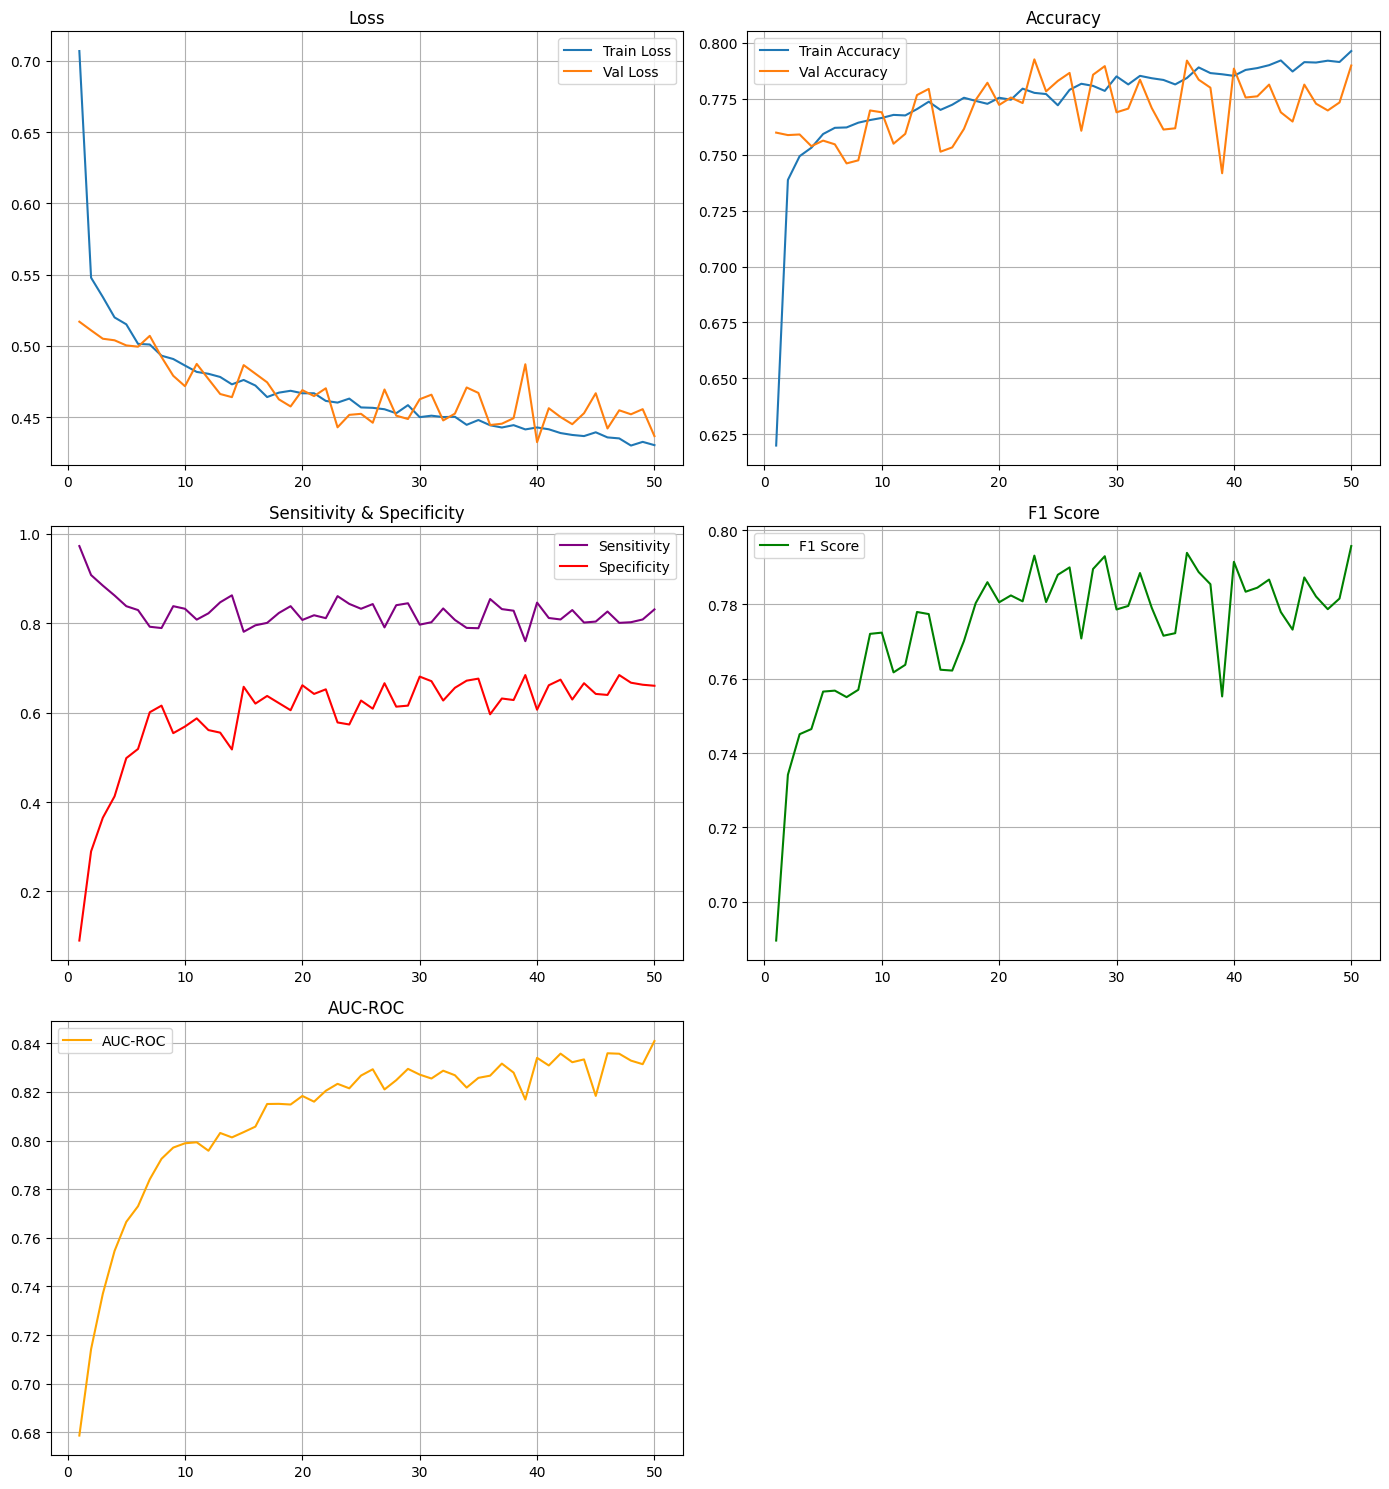

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(14, 15))

# Loss subplot
axs[0, 0].plot(range(1, epochs + 1), train_losses, label='Train Loss')
axs[0, 0].plot(range(1, epochs + 1), val_losses, label='Val Loss')
axs[0, 0].set_title('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Accuracy subplot
axs[0, 1].plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
axs[0, 1].plot(range(1, epochs + 1), val_accuracies, label='Val Accuracy')
axs[0, 1].set_title('Accuracy')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Combined Sensitivity and Specificity subplot
axs[1, 0].plot(range(1, epochs + 1), sensitivities, label='Sensitivity', color='purple')
axs[1, 0].plot(range(1, epochs + 1), specificities, label='Specificity', color='red')
axs[1, 0].set_title('Sensitivity & Specificity')
axs[1, 0].legend()
axs[1, 0].grid(True)

# F1 scores subplot
axs[1, 1].plot(range(1, epochs + 1), f1_scores, label='F1 Score', color='green')
axs[1, 1].set_title('F1 Score')
axs[1, 1].legend()
axs[1, 1].grid(True)

# AUC-ROC subplot (new)
axs[2, 0].plot(range(1, epochs + 1), auc_scores, label='AUC-ROC', color='orange')
axs[2, 0].set_title('AUC-ROC')
axs[2, 0].legend()
axs[2, 0].grid(True)

# Optionally leave axs[2, 1] empty or use for something else
axs[2, 1].axis('off')  # turn off the last unused subplot

plt.tight_layout()
plt.savefig("training_metrics_subplot_with_auc.png")
plt.show()

## Test Model - Binary (50 epochs)

In [10]:
print("Evaluating model on test dataset...")
test_loss, test_acc, test_f1, test_sensitivity, test_specificity, test_auc = evaluate_binary(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print("TEST RESULTS")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test Sensitivity: {test_sensitivity:.4f}")
print(f"Test Specificity: {test_specificity:.4f}")
if test_auc is not None:
    print(f"Test AUC-ROC: {test_auc:.4f}")
else:
    print("Test AUC-ROC: N/A")
print(f"{'='*50}")

Evaluating model on test dataset...

TEST RESULTS
Test Loss: 0.4451
Test Accuracy: 0.7819
Test F1-Score: 0.7865
Test Sensitivity: 0.8344
Test Specificity: 0.6169
Test AUC-ROC: 0.8326


## Train - Binary (Early Stopping)

In [19]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
f1_scores = []
sensitivities = []
specificities = []
auc_scores = []

# Initialize early stopping
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

epochs = 50  # Maximum epochs
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, f1, sensitivity, specificity, auc = evaluate_binary(model, val_loader, criterion, device)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    auc_scores.append(auc)
    
    print(
        f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f} | "
        f"AUC-ROC: {auc:.4f}" if auc is not None else "AUC-ROC: N/A"
    )
    
    # Check early stopping
    if early_stopping(val_loss):
        print(f"Early stopping triggered at epoch {epoch}")
        print(f"Best validation loss was {early_stopping.best_loss:.4f}")
        break

print(f"Training completed after {len(train_losses)} epochs")

Epoch 01 | Train Loss: 0.5958 | Val Loss: 0.5418 | Train Acc: 0.7074 | Val Acc: 0.7290 | F1: 0.7227 | Sensitivity: 0.8412 | Specificity: 0.3763 | AUC-ROC: 0.7000
Epoch 02 | Train Loss: 0.5420 | Val Loss: 0.5336 | Train Acc: 0.7468 | Val Acc: 0.7249 | F1: 0.7255 | Sensitivity: 0.8165 | Specificity: 0.4367 | AUC-ROC: 0.7233
Epoch 03 | Train Loss: 0.5240 | Val Loss: 0.5376 | Train Acc: 0.7500 | Val Acc: 0.7304 | F1: 0.7374 | Sensitivity: 0.7944 | Specificity: 0.5291 | AUC-ROC: 0.7438
Epoch 04 | Train Loss: 0.5201 | Val Loss: 0.5360 | Train Acc: 0.7556 | Val Acc: 0.7238 | F1: 0.7364 | Sensitivity: 0.7614 | Specificity: 0.6055 | AUC-ROC: 0.7593
Epoch 05 | Train Loss: 0.5094 | Val Loss: 0.5283 | Train Acc: 0.7590 | Val Acc: 0.7180 | F1: 0.7343 | Sensitivity: 0.7321 | Specificity: 0.6739 | AUC-ROC: 0.7762
Epoch 06 | Train Loss: 0.5069 | Val Loss: 0.5253 | Train Acc: 0.7608 | Val Acc: 0.7274 | F1: 0.7421 | Sensitivity: 0.7473 | Specificity: 0.6648 | AUC-ROC: 0.7840
Epoch 07 | Train Loss: 0.496

## Plot Results - Binary (Early Stopping)

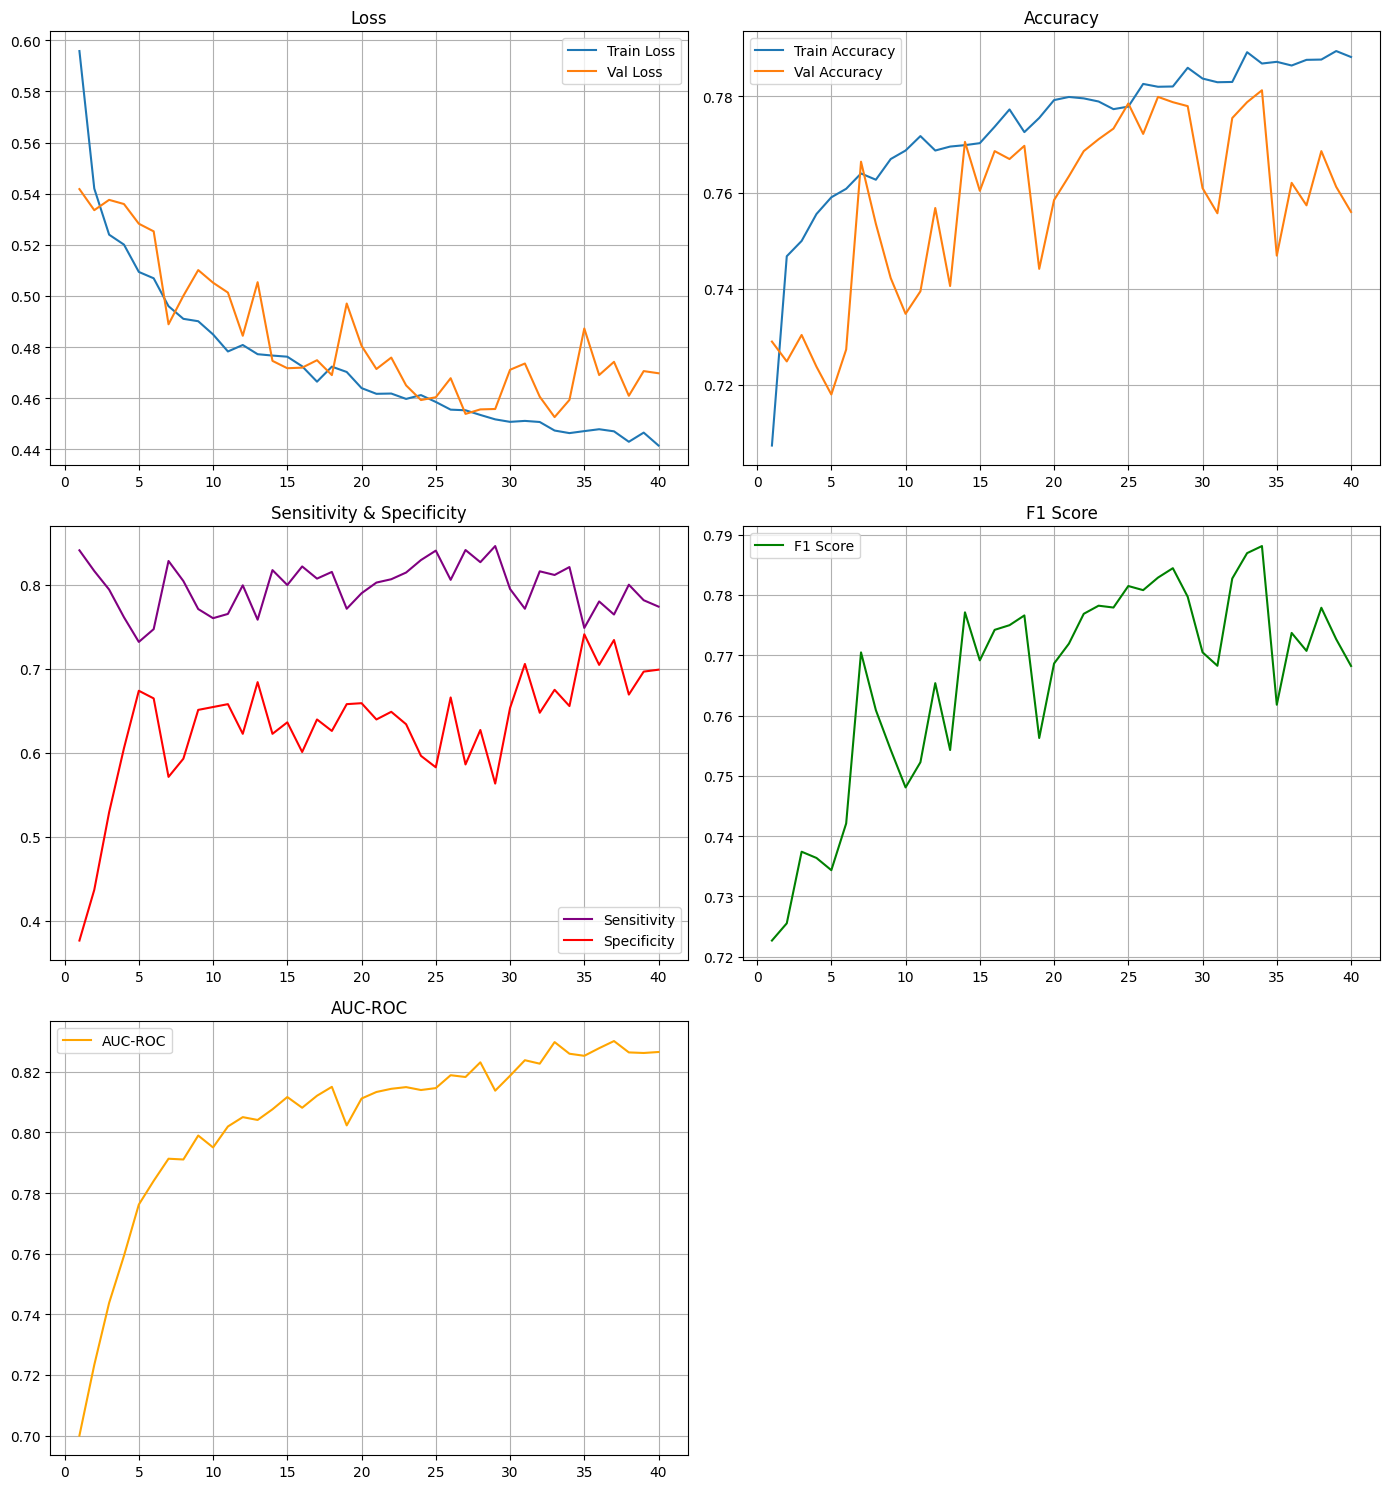

In [21]:
fig, axs = plt.subplots(3, 2, figsize=(14, 15))
epochs=40

# Loss subplot
axs[0, 0].plot(range(1, epochs + 1), train_losses, label='Train Loss')
axs[0, 0].plot(range(1, epochs + 1), val_losses, label='Val Loss')
axs[0, 0].set_title('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Accuracy subplot
axs[0, 1].plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
axs[0, 1].plot(range(1, epochs + 1), val_accuracies, label='Val Accuracy')
axs[0, 1].set_title('Accuracy')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Combined Sensitivity and Specificity subplot
axs[1, 0].plot(range(1, epochs + 1), sensitivities, label='Sensitivity', color='purple')
axs[1, 0].plot(range(1, epochs + 1), specificities, label='Specificity', color='red')
axs[1, 0].set_title('Sensitivity & Specificity')
axs[1, 0].legend()
axs[1, 0].grid(True)

# F1 scores subplot
axs[1, 1].plot(range(1, epochs + 1), f1_scores, label='F1 Score', color='green')
axs[1, 1].set_title('F1 Score')
axs[1, 1].legend()
axs[1, 1].grid(True)

# AUC-ROC subplot (new)
axs[2, 0].plot(range(1, epochs + 1), auc_scores, label='AUC-ROC', color='orange')
axs[2, 0].set_title('AUC-ROC')
axs[2, 0].legend()
axs[2, 0].grid(True)

# Optionally leave axs[2, 1] empty or use for something else
axs[2, 1].axis('off')  # turn off the last unused subplot

plt.tight_layout()
plt.savefig("training_metrics_subplot_with_auc.png")
plt.show()

## Test Results - Binary (Early Stopping)

In [23]:
print("Evaluating model on test dataset...")
test_loss, test_acc, test_f1, test_sensitivity, test_specificity, test_auc = evaluate_binary(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print("TEST RESULTS")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test Sensitivity: {test_sensitivity:.4f}")
print(f"Test Specificity: {test_specificity:.4f}")
if test_auc is not None:
    print(f"Test AUC-ROC: {test_auc:.4f}")
else:
    print("Test AUC-ROC: N/A")
print(f"{'='*50}")

Evaluating model on test dataset...

TEST RESULTS
Test Loss: 0.4684
Test Accuracy: 0.7599
Test F1-Score: 0.7714
Test Sensitivity: 0.7807
Test Specificity: 0.6944
Test AUC-ROC: 0.8268


## Train - Binary (30 epochs)

In [28]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
f1_scores = []
sensitivities = []
specificities = []
auc_scores = []

epochs = 30
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, f1, sensitivity, specificity, auc = evaluate_binary(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    auc_scores.append(auc)  # append AUC

    print(
        f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f} | "
        f"AUC-ROC: {auc:.4f}" if auc is not None else "AUC-ROC: N/A"
    )

Epoch 01 | Train Loss: 0.6241 | Val Loss: 0.5101 | Train Acc: 0.6863 | Val Acc: 0.7618 | F1: 0.7213 | Sensitivity: 0.9380 | Specificity: 0.2075 | AUC-ROC: 0.7128
Epoch 02 | Train Loss: 0.5593 | Val Loss: 0.5165 | Train Acc: 0.7345 | Val Acc: 0.7466 | F1: 0.7373 | Sensitivity: 0.8626 | Specificity: 0.3820 | AUC-ROC: 0.7302
Epoch 03 | Train Loss: 0.5432 | Val Loss: 0.5091 | Train Acc: 0.7439 | Val Acc: 0.7651 | F1: 0.7569 | Sensitivity: 0.8731 | Specificity: 0.4253 | AUC-ROC: 0.7517
Epoch 04 | Train Loss: 0.5300 | Val Loss: 0.5033 | Train Acc: 0.7528 | Val Acc: 0.7568 | F1: 0.7549 | Sensitivity: 0.8466 | Specificity: 0.4743 | AUC-ROC: 0.7636
Epoch 05 | Train Loss: 0.5151 | Val Loss: 0.5109 | Train Acc: 0.7548 | Val Acc: 0.7491 | F1: 0.7554 | Sensitivity: 0.8078 | Specificity: 0.5644 | AUC-ROC: 0.7737
Epoch 06 | Train Loss: 0.5143 | Val Loss: 0.5155 | Train Acc: 0.7546 | Val Acc: 0.7466 | F1: 0.7563 | Sensitivity: 0.7886 | Specificity: 0.6146 | AUC-ROC: 0.7830
Epoch 07 | Train Loss: 0.508

## Plot Results - Binary (30 epochs)

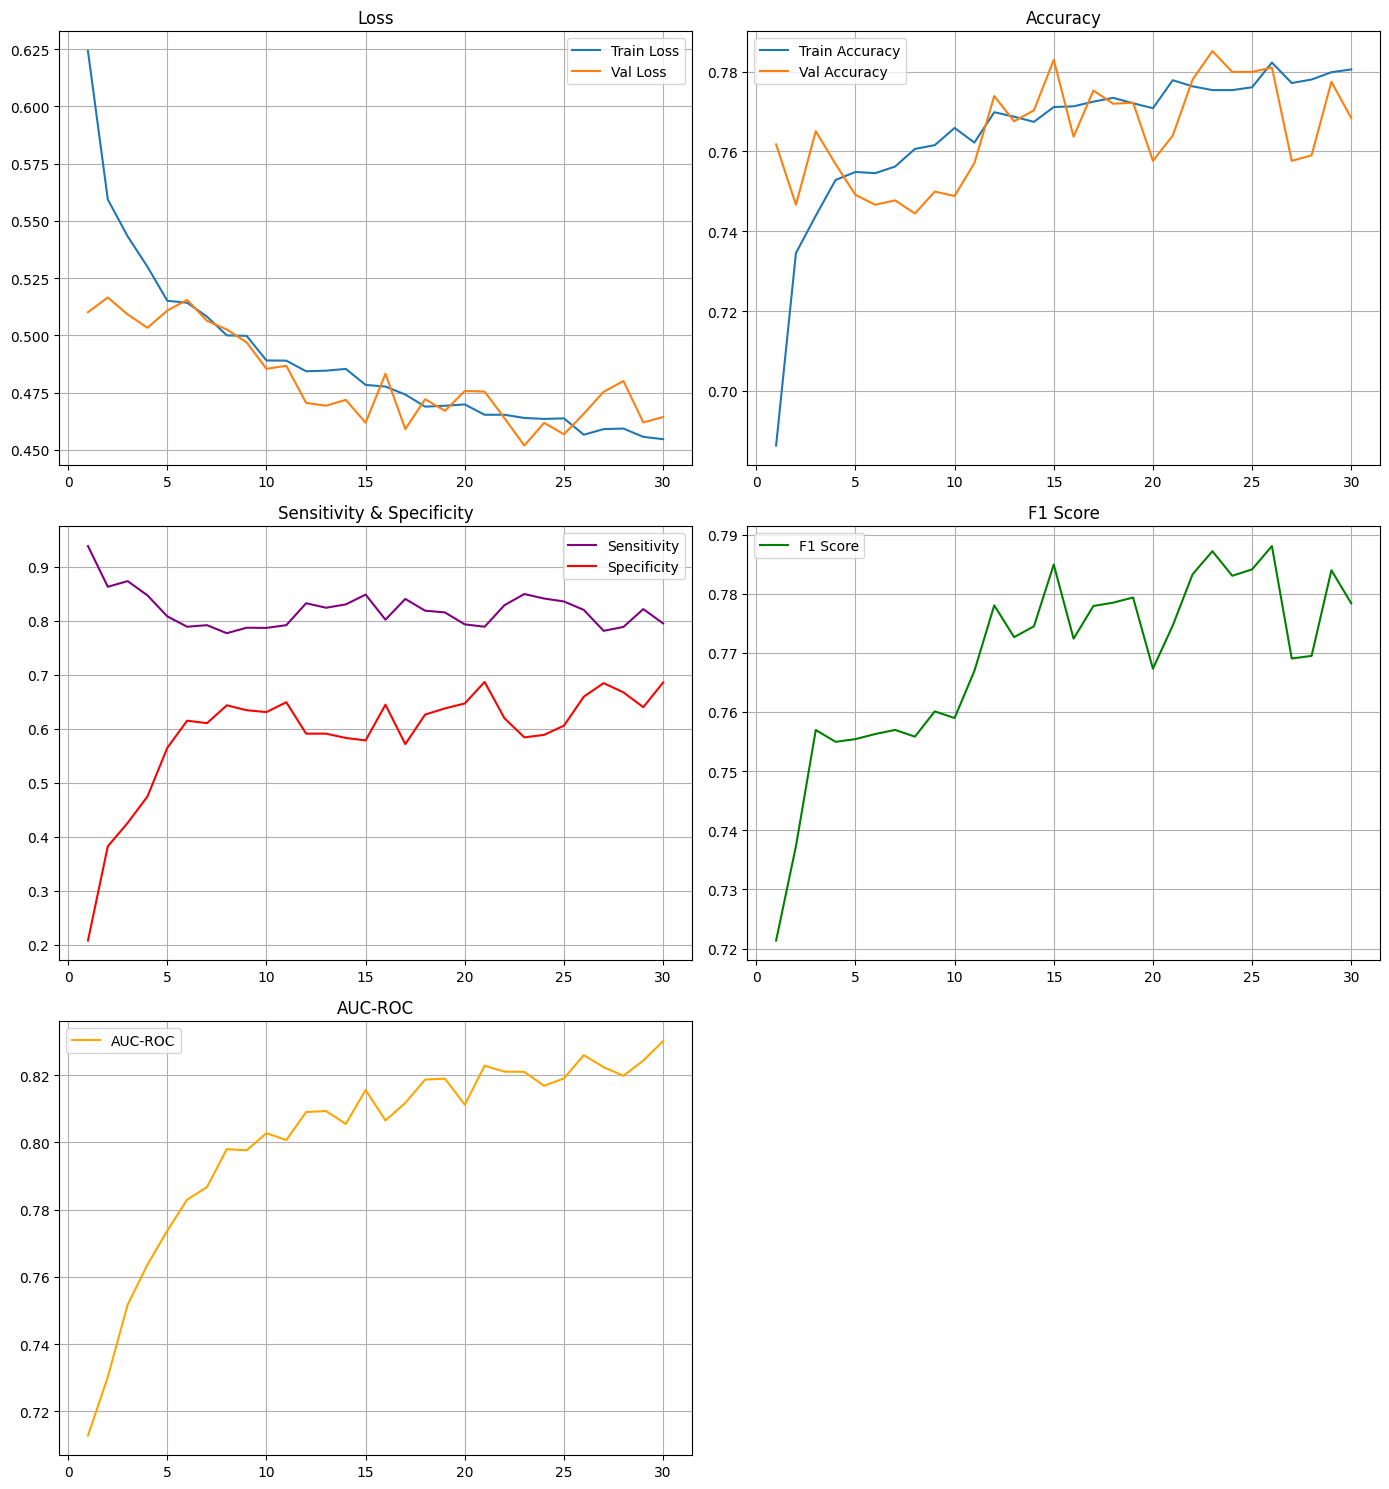

In [29]:
fig, axs = plt.subplots(3, 2, figsize=(14, 15))

# Loss subplot
axs[0, 0].plot(range(1, epochs + 1), train_losses, label='Train Loss')
axs[0, 0].plot(range(1, epochs + 1), val_losses, label='Val Loss')
axs[0, 0].set_title('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Accuracy subplot
axs[0, 1].plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
axs[0, 1].plot(range(1, epochs + 1), val_accuracies, label='Val Accuracy')
axs[0, 1].set_title('Accuracy')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Combined Sensitivity and Specificity subplot
axs[1, 0].plot(range(1, epochs + 1), sensitivities, label='Sensitivity', color='purple')
axs[1, 0].plot(range(1, epochs + 1), specificities, label='Specificity', color='red')
axs[1, 0].set_title('Sensitivity & Specificity')
axs[1, 0].legend()
axs[1, 0].grid(True)

# F1 scores subplot
axs[1, 1].plot(range(1, epochs + 1), f1_scores, label='F1 Score', color='green')
axs[1, 1].set_title('F1 Score')
axs[1, 1].legend()
axs[1, 1].grid(True)

# AUC-ROC subplot (new)
axs[2, 0].plot(range(1, epochs + 1), auc_scores, label='AUC-ROC', color='orange')
axs[2, 0].set_title('AUC-ROC')
axs[2, 0].legend()
axs[2, 0].grid(True)

# Optionally leave axs[2, 1] empty or use for something else
axs[2, 1].axis('off')  # turn off the last unused subplot

plt.tight_layout()
plt.savefig("training_metrics_subplot_with_auc.png")
plt.show()

## Test Results - Binary (30 epochs)

In [30]:
print("Evaluating model on test dataset...")
test_loss, test_acc, test_f1, test_sensitivity, test_specificity, test_auc = evaluate_binary(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print("TEST RESULTS")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test Sensitivity: {test_sensitivity:.4f}")
print(f"Test Specificity: {test_specificity:.4f}")
if test_auc is not None:
    print(f"Test AUC-ROC: {test_auc:.4f}")
else:
    print("Test AUC-ROC: N/A")
print(f"{'='*50}")

Evaluating model on test dataset...

TEST RESULTS
Test Loss: 0.4742
Test Accuracy: 0.7660
Test F1-Score: 0.7756
Test Sensitivity: 0.7967
Test Specificity: 0.6693
Test AUC-ROC: 0.8165


# Multiclass Testing

## Extract Features - Multiclass

In [31]:
# Select feature columns
feature_cols = [col for col in mwr_df_simple.columns if col.endswith('int') or col.endswith('sk')]
mwr_df_simple['features'] = mwr_df_simple[feature_cols].values.tolist()

# Prepare labels and text targets
mwr_df_simple['class_label'] = mwr_df_simple['r:Th'].astype(int)

## Split Data into Test and Train

In [32]:
train_simple_df, temp_simple_df = train_test_split(
    mwr_df_simple, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df_simple['r:Th']
)

val_simple_df, test_simple_df = train_test_split(
    temp_simple_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_simple_df['r:Th']
)

In [33]:
train_dataset = TabularDataset(train_simple_df)
val_dataset = TabularDataset(val_simple_df)
test_dataset = TabularDataset(test_simple_df)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Initialise Model - Multiclass

In [34]:
model = ClassificationModel(num_features=44, num_classes=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

## Train Model - Multiclass (50 epochs)

In [35]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
f1_scores = []
sensitivities = []
specificities = []
sensitivities_arr = []  
specificities_arr = []
auc_scores = []


epochs=50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, f1, sensitivity, specificity, sensitivity_arr, specificity_arr, auc = evaluate_multiclass(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    sensitivities_arr.append(sensitivity_arr)
    specificities_arr.append(specificity_arr)
    auc_scores.append(auc)


    print(
        f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}"
    )
    for i, (sens, spec) in enumerate(zip(sensitivity_arr, specificity_arr)):
        print(f"  Class {i}: Sensitivity: {sens:.4f}, Specificity: {spec:.4f}")

Epoch 01 | Train Loss: 1.7289 | Val Loss: 1.4505 | Train Acc: 0.3078 | Val Acc: 0.4085 | F1: 0.3657 | Sensitivity: 0.2541 | Specificity: 0.8647
  Class 0: Sensitivity: 0.5165, Specificity: 0.7045
  Class 1: Sensitivity: 0.6546, Specificity: 0.6509
  Class 2: Sensitivity: 0.3121, Specificity: 0.8382
  Class 3: Sensitivity: 0.0000, Specificity: 0.9997
  Class 4: Sensitivity: 0.0034, Specificity: 0.9997
  Class 5: Sensitivity: 0.0381, Specificity: 0.9953
Epoch 02 | Train Loss: 1.5337 | Val Loss: 1.4030 | Train Acc: 0.3762 | Val Acc: 0.4107 | F1: 0.3570 | Sensitivity: 0.2695 | Specificity: 0.8660
  Class 0: Sensitivity: 0.6203, Specificity: 0.6719
  Class 1: Sensitivity: 0.6822, Specificity: 0.6157
  Class 2: Sensitivity: 0.1916, Specificity: 0.9189
  Class 3: Sensitivity: 0.0183, Specificity: 0.9991
  Class 4: Sensitivity: 0.0068, Specificity: 0.9982
  Class 5: Sensitivity: 0.0975, Specificity: 0.9921
Epoch 03 | Train Loss: 1.4756 | Val Loss: 1.3607 | Train Acc: 0.4006 | Val Acc: 0.4336 |

Epoch 19 | Train Loss: 1.2643 | Val Loss: 1.2326 | Train Acc: 0.4743 | Val Acc: 0.4820 | F1: 0.4537 | Sensitivity: 0.3508 | Specificity: 0.8837
  Class 0: Sensitivity: 0.7548, Specificity: 0.6838
  Class 1: Sensitivity: 0.6051, Specificity: 0.7968
  Class 2: Sensitivity: 0.3290, Specificity: 0.8573
  Class 3: Sensitivity: 0.0183, Specificity: 0.9986
  Class 4: Sensitivity: 0.1096, Specificity: 0.9815
  Class 5: Sensitivity: 0.2881, Specificity: 0.9844
Epoch 20 | Train Loss: 1.2588 | Val Loss: 1.2079 | Train Acc: 0.4755 | Val Acc: 0.4982 | F1: 0.4722 | Sensitivity: 0.3632 | Specificity: 0.8871
  Class 0: Sensitivity: 0.6556, Specificity: 0.7781
  Class 1: Sensitivity: 0.6917, Specificity: 0.7426
  Class 2: Sensitivity: 0.3738, Specificity: 0.8483
  Class 3: Sensitivity: 0.0367, Specificity: 0.9980
  Class 4: Sensitivity: 0.0993, Specificity: 0.9791
  Class 5: Sensitivity: 0.3220, Specificity: 0.9762
Epoch 21 | Train Loss: 1.2536 | Val Loss: 1.2250 | Train Acc: 0.4820 | Val Acc: 0.4946 |

Epoch 37 | Train Loss: 1.2015 | Val Loss: 1.1486 | Train Acc: 0.4975 | Val Acc: 0.5351 | F1: 0.5149 | Sensitivity: 0.4069 | Specificity: 0.8964
  Class 0: Sensitivity: 0.7263, Specificity: 0.7828
  Class 1: Sensitivity: 0.6622, Specificity: 0.8061
  Class 2: Sensitivity: 0.4327, Specificity: 0.8495
  Class 3: Sensitivity: 0.0459, Specificity: 0.9972
  Class 4: Sensitivity: 0.1507, Specificity: 0.9752
  Class 5: Sensitivity: 0.4237, Specificity: 0.9673
Epoch 38 | Train Loss: 1.1975 | Val Loss: 1.1627 | Train Acc: 0.5042 | Val Acc: 0.5263 | F1: 0.5037 | Sensitivity: 0.3976 | Specificity: 0.8941
  Class 0: Sensitivity: 0.7229, Specificity: 0.7741
  Class 1: Sensitivity: 0.6755, Specificity: 0.7852
  Class 2: Sensitivity: 0.4075, Specificity: 0.8585
  Class 3: Sensitivity: 0.0826, Specificity: 0.9960
  Class 4: Sensitivity: 0.1199, Specificity: 0.9779
  Class 5: Sensitivity: 0.3771, Specificity: 0.9726
Epoch 39 | Train Loss: 1.1944 | Val Loss: 1.1615 | Train Acc: 0.5029 | Val Acc: 0.5175 |

## Plot Results - Multiclass (50 epochs)

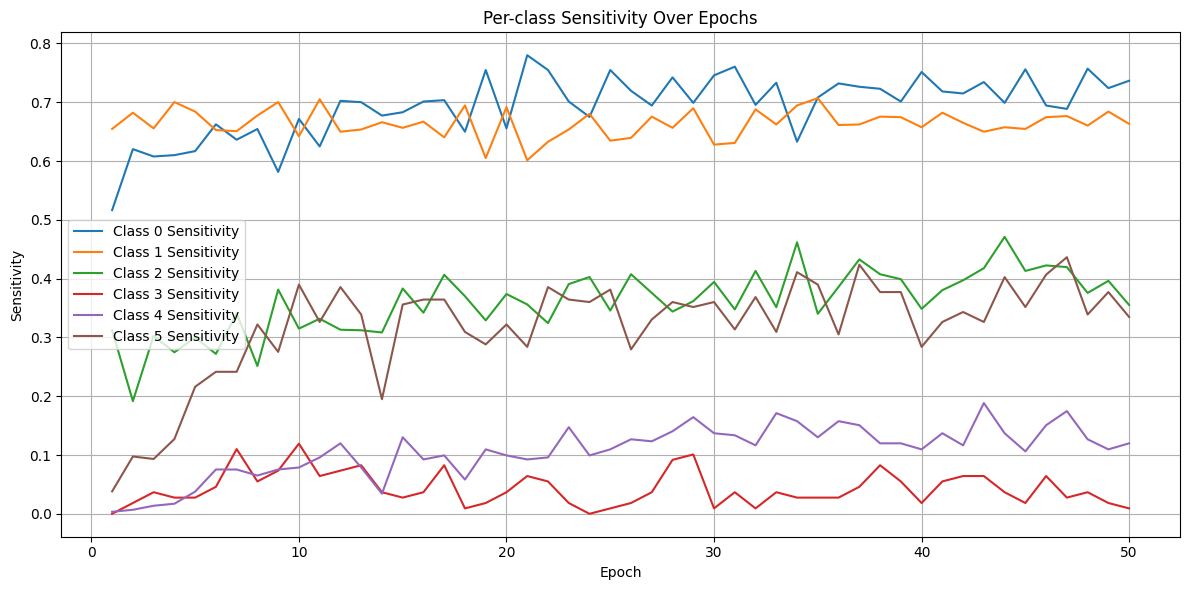

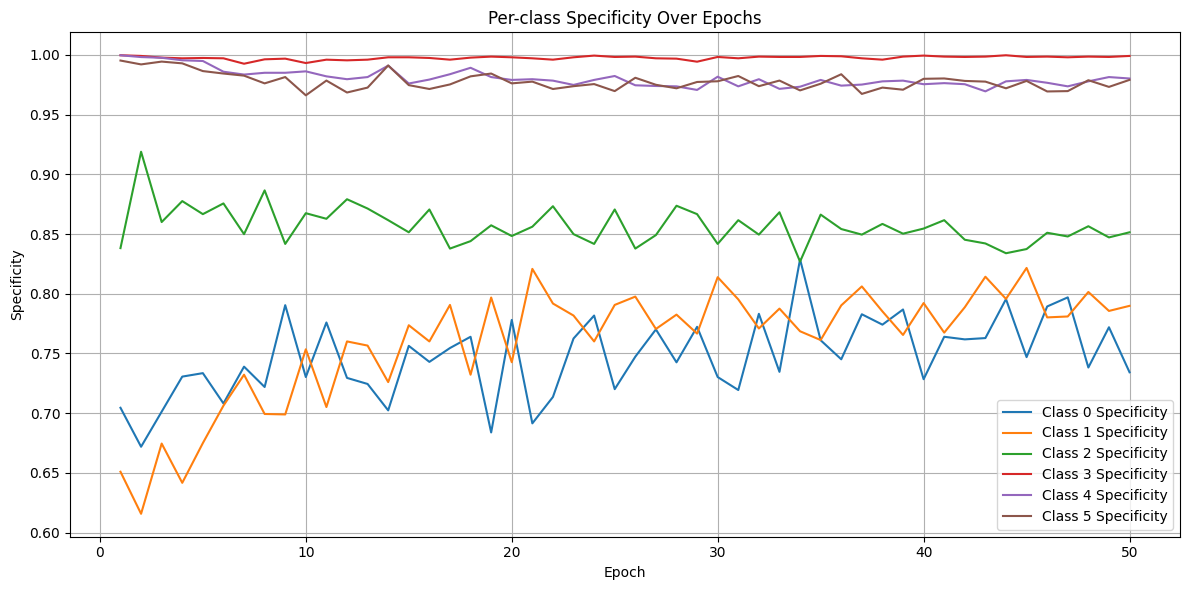

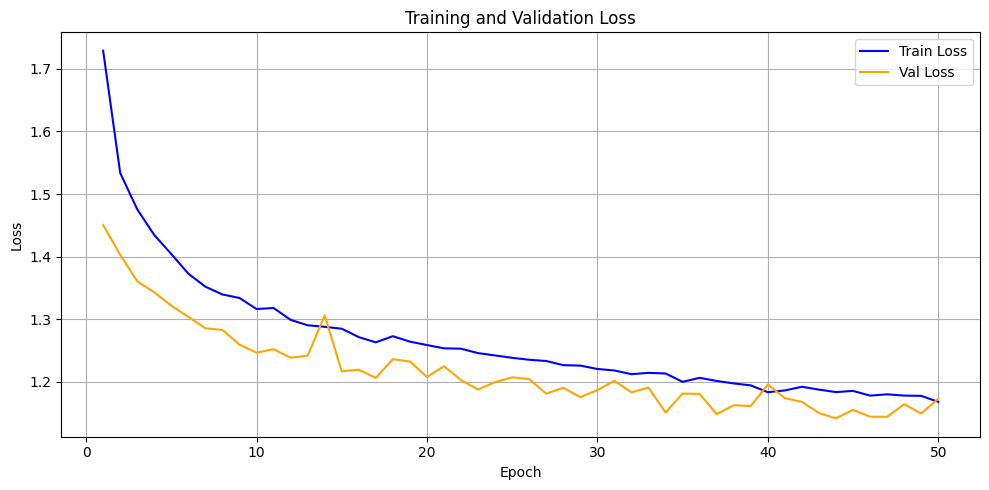

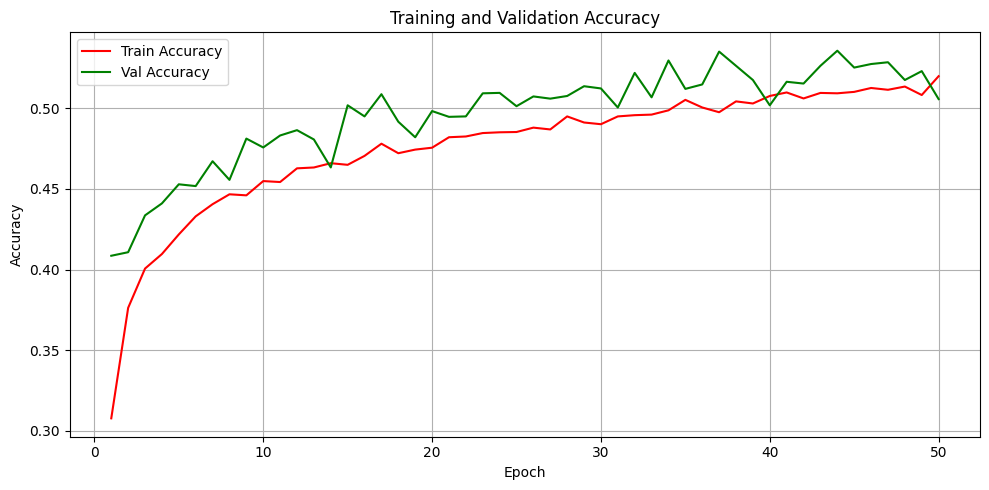

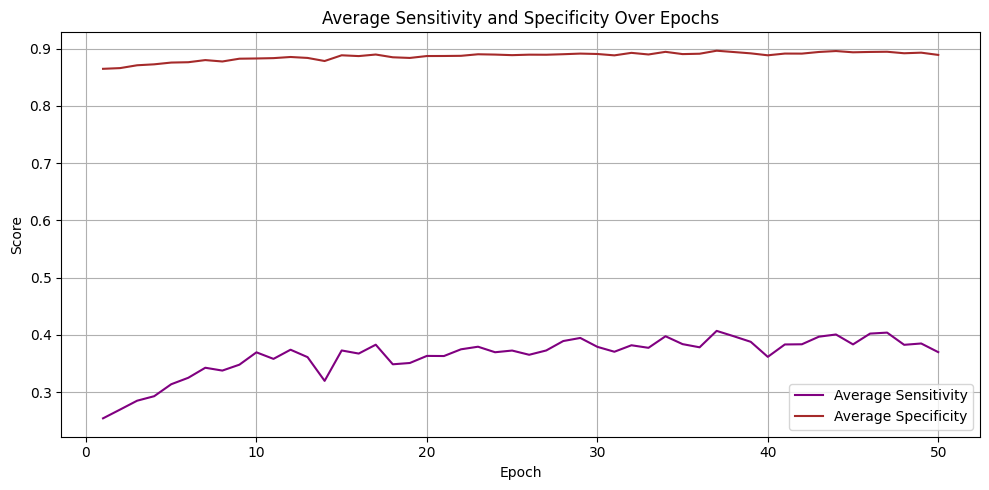

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists of arrays to numpy arrays for easier indexing
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

epochs = sensitivities_arr.shape[0]
n_classes = sensitivities_arr.shape[1]
epochs_range = range(1, epochs + 1)

# Plot sensitivity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, sensitivities_arr[:, i], label=f"Class {i} Sensitivity")
plt.xlabel("Epoch")
plt.ylabel("Sensitivity")
plt.title("Per-class Sensitivity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot specificity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, specificities_arr[:, i], label=f"Class {i} Specificity")
plt.xlabel("Epoch")
plt.ylabel("Specificity")
plt.title("Per-class Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt

epochs = len(train_losses)
epochs_range = range(1, epochs + 1)
n_classes = sensitivities_arr.shape[1]

# Convert lists of arrays to numpy arrays (if not already)
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

# 1) Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label="Train Loss", color="blue")
plt.plot(epochs_range, val_losses, label="Val Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy", color="red")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Plot average sensitivity and specificity across classes
avg_sensitivity = np.mean(sensitivities_arr, axis=1)
avg_specificity = np.mean(specificities_arr, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, avg_sensitivity, label="Average Sensitivity", color="purple")
plt.plot(epochs_range, avg_specificity, label="Average Specificity", color="brown")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Average Sensitivity and Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Test Results - Multiclass (50 epochs)

In [37]:
print("Evaluating model on test dataset...")
(
    test_loss,
    test_acc,
    test_f1,
    test_sensitivity,
    test_specificity,
    test_sensitivity_arr,
    test_specificity_arr,
    test_auc
) = evaluate_multiclass(model, test_loader, criterion, device)

print(f"\n{'='*60}")
print("MULTICLASS TEST RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Mean Sensitivity: {test_sensitivity:.4f}")
print(f"Mean Specificity: {test_specificity:.4f}")
if test_auc is not None:
    print(f"Test AUC-ROC (macro avg): {test_auc:.4f}")
else:
    print("Test AUC-ROC: N/A")
print(f"{'-'*60}")
print("Per-Class Sensitivity:")
for i, s in enumerate(test_sensitivity_arr):
    print(f"  Class {i}: {s:.4f}")
print("Per-Class Specificity:")
for i, s in enumerate(test_specificity_arr):
    print(f"  Class {i}: {s:.4f}")
print(f"{'='*60}")

Evaluating model on test dataset...

MULTICLASS TEST RESULTS
Test Loss: 1.1788
Test Accuracy: 0.5036
Test F1-Score: 0.4801
Mean Sensitivity: 0.3809
Mean Specificity: 0.8884
Test AUC-ROC (macro avg): 0.8356
------------------------------------------------------------
Per-Class Sensitivity:
  Class 0: 0.7104
  Class 1: 0.6575
  Class 2: 0.3641
  Class 3: 0.0826
  Class 4: 0.1233
  Class 5: 0.3475
Per-Class Specificity:
  Class 0: 0.7314
  Class 1: 0.7814
  Class 2: 0.8546
  Class 3: 0.9989
  Class 4: 0.9806
  Class 5: 0.9832


## Set-up Oversampling

In [42]:
# Separate minority and majority classes
dfs = [train_simple_df[train_simple_df['class_label'] == i] for i in train_simple_df['class_label'].unique()]
max_len = max(len(df) for df in dfs)

# Oversample each class to match the majority class
oversampled_dfs = [resample(df, replace=True, n_samples=max_len, random_state=42) for df in dfs]

# Concatenate them back
train_df_balanced = pd.concat(oversampled_dfs).sample(frac=1, random_state=42)  # shuffle

# training dataset
train_dataset = TabularDataset(train_df_balanced)

## Initialise Model

In [43]:
model = ClassificationModel(num_features=44, num_classes=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

## Train - Multiclass (50 epochs + oversampling)

In [44]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
f1_scores = []
sensitivities = []
specificities = []
sensitivities_arr = []  
specificities_arr = []
auc_scores = []


epochs=50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, f1, sensitivity, specificity, sensitivity_arr, specificity_arr, auc = evaluate_multiclass(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    sensitivities_arr.append(sensitivity_arr)
    specificities_arr.append(specificity_arr)
    auc_scores.append(auc)


    print(
        f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}"
    )
    for i, (sens, spec) in enumerate(zip(sensitivity_arr, specificity_arr)):
        print(f"  Class {i}: Sensitivity: {sens:.4f}, Specificity: {spec:.4f}")

Epoch 01 | Train Loss: 1.7423 | Val Loss: 1.4664 | Train Acc: 0.3201 | Val Acc: 0.4050 | F1: 0.3490 | Sensitivity: 0.2509 | Specificity: 0.8640
  Class 0: Sensitivity: 0.5815, Specificity: 0.6962
  Class 1: Sensitivity: 0.6879, Specificity: 0.6041
  Class 2: Sensitivity: 0.2196, Specificity: 0.8873
  Class 3: Sensitivity: 0.0000, Specificity: 0.9994
  Class 4: Sensitivity: 0.0034, Specificity: 0.9988
  Class 5: Sensitivity: 0.0127, Specificity: 0.9979
Epoch 02 | Train Loss: 1.5385 | Val Loss: 1.4031 | Train Acc: 0.3797 | Val Acc: 0.4289 | F1: 0.3832 | Sensitivity: 0.2744 | Specificity: 0.8691
  Class 0: Sensitivity: 0.5485, Specificity: 0.7487
  Class 1: Sensitivity: 0.7108, Specificity: 0.6014
  Class 2: Sensitivity: 0.2869, Specificity: 0.8710
  Class 3: Sensitivity: 0.0000, Specificity: 0.9994
  Class 4: Sensitivity: 0.0068, Specificity: 0.9991
  Class 5: Sensitivity: 0.0932, Specificity: 0.9950
Epoch 03 | Train Loss: 1.4891 | Val Loss: 1.3824 | Train Acc: 0.3951 | Val Acc: 0.4237 |

Epoch 19 | Train Loss: 1.2761 | Val Loss: 1.2000 | Train Acc: 0.4704 | Val Acc: 0.5103 | F1: 0.4850 | Sensitivity: 0.3776 | Specificity: 0.8899
  Class 0: Sensitivity: 0.6613, Specificity: 0.7886
  Class 1: Sensitivity: 0.6784, Specificity: 0.7558
  Class 2: Sensitivity: 0.4140, Specificity: 0.8425
  Class 3: Sensitivity: 0.0459, Specificity: 0.9972
  Class 4: Sensitivity: 0.0719, Specificity: 0.9856
  Class 5: Sensitivity: 0.3941, Specificity: 0.9694
Epoch 20 | Train Loss: 1.2681 | Val Loss: 1.1978 | Train Acc: 0.4782 | Val Acc: 0.5155 | F1: 0.4895 | Sensitivity: 0.3849 | Specificity: 0.8912
  Class 0: Sensitivity: 0.6944, Specificity: 0.7759
  Class 1: Sensitivity: 0.6775, Specificity: 0.7682
  Class 2: Sensitivity: 0.4028, Specificity: 0.8499
  Class 3: Sensitivity: 0.0642, Specificity: 0.9972
  Class 4: Sensitivity: 0.0719, Specificity: 0.9856
  Class 5: Sensitivity: 0.3983, Specificity: 0.9703
Epoch 21 | Train Loss: 1.2590 | Val Loss: 1.2087 | Train Acc: 0.4773 | Val Acc: 0.5111 |

Epoch 37 | Train Loss: 1.2034 | Val Loss: 1.1829 | Train Acc: 0.5037 | Val Acc: 0.5133 | F1: 0.4843 | Sensitivity: 0.3783 | Specificity: 0.8908
  Class 0: Sensitivity: 0.7286, Specificity: 0.7469
  Class 1: Sensitivity: 0.6775, Specificity: 0.7856
  Class 2: Sensitivity: 0.3701, Specificity: 0.8550
  Class 3: Sensitivity: 0.0183, Specificity: 0.9991
  Class 4: Sensitivity: 0.0856, Specificity: 0.9847
  Class 5: Sensitivity: 0.3898, Specificity: 0.9732
Epoch 38 | Train Loss: 1.2033 | Val Loss: 1.1525 | Train Acc: 0.5036 | Val Acc: 0.5257 | F1: 0.5034 | Sensitivity: 0.3907 | Specificity: 0.8933
  Class 0: Sensitivity: 0.6431, Specificity: 0.8147
  Class 1: Sensitivity: 0.6927, Specificity: 0.7686
  Class 2: Sensitivity: 0.4542, Specificity: 0.8265
  Class 3: Sensitivity: 0.0275, Specificity: 0.9980
  Class 4: Sensitivity: 0.1027, Specificity: 0.9806
  Class 5: Sensitivity: 0.4237, Specificity: 0.9712
Epoch 39 | Train Loss: 1.1989 | Val Loss: 1.1649 | Train Acc: 0.5048 | Val Acc: 0.5208 |

## Plot Results - Multiclass (50 epochs + oversampling)

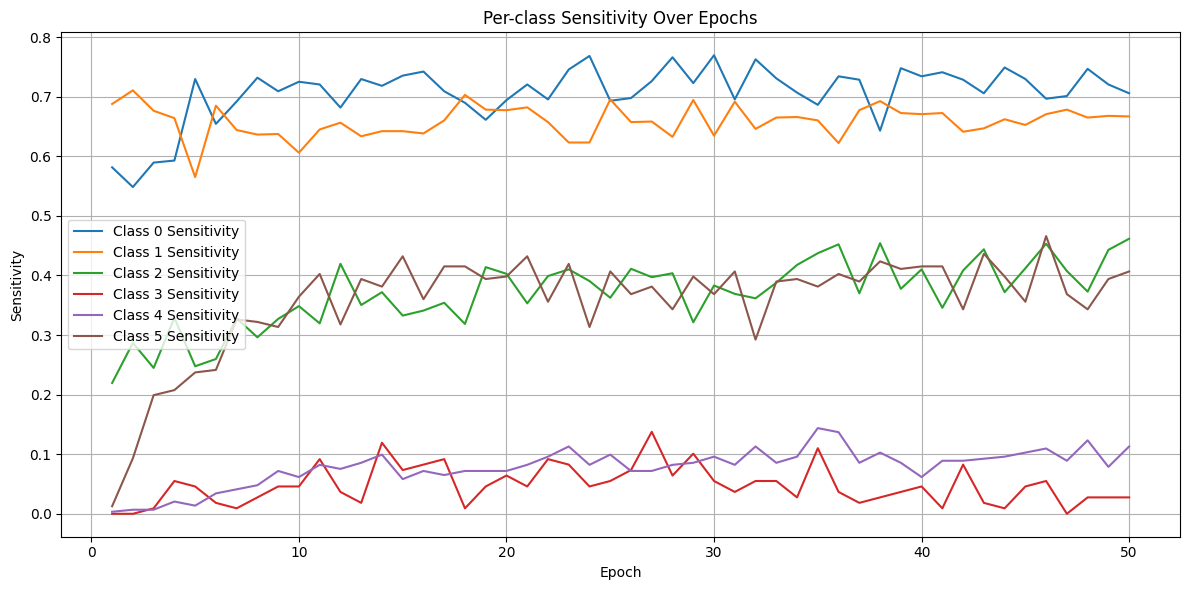

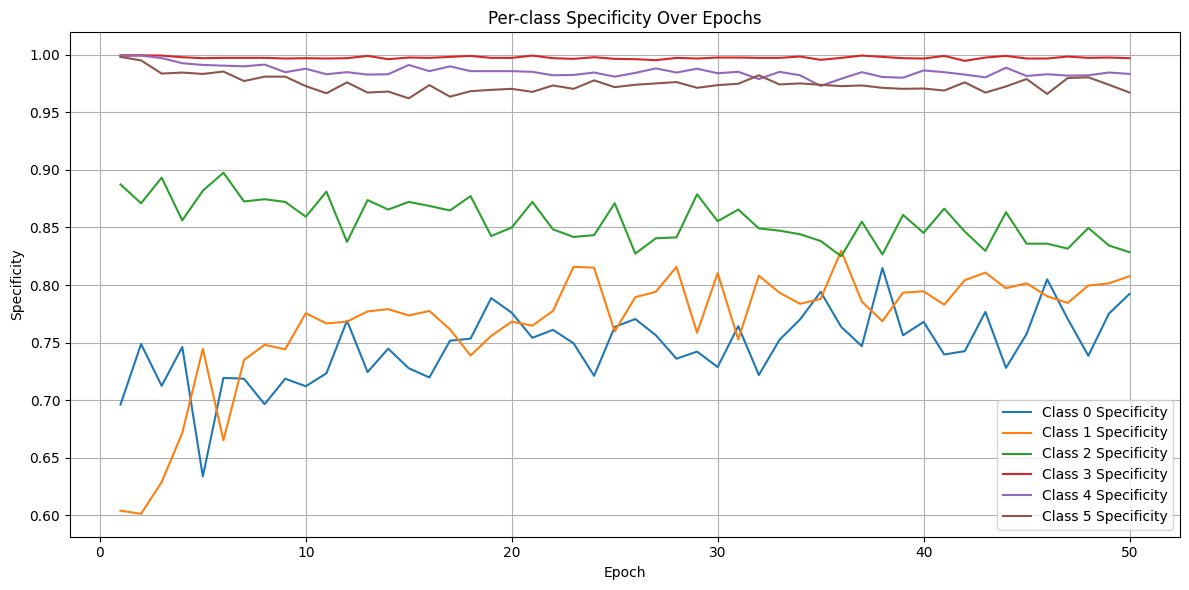

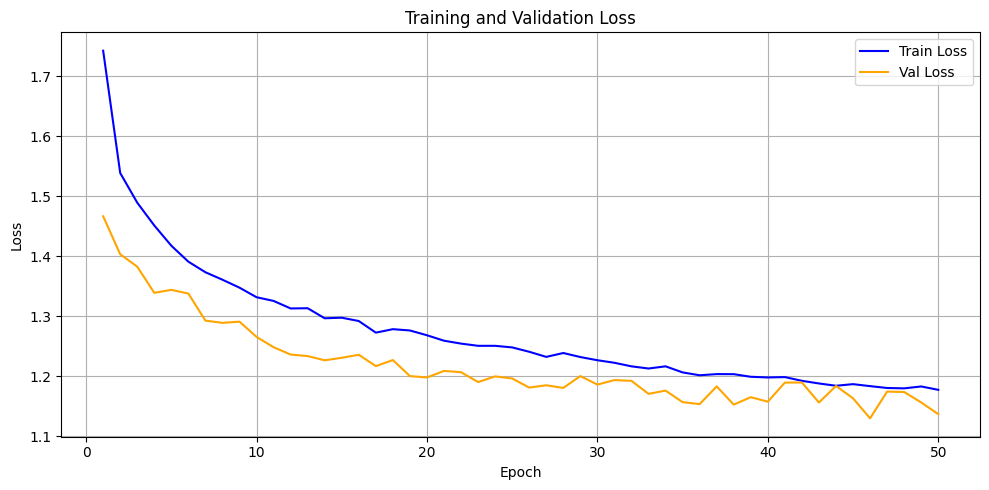

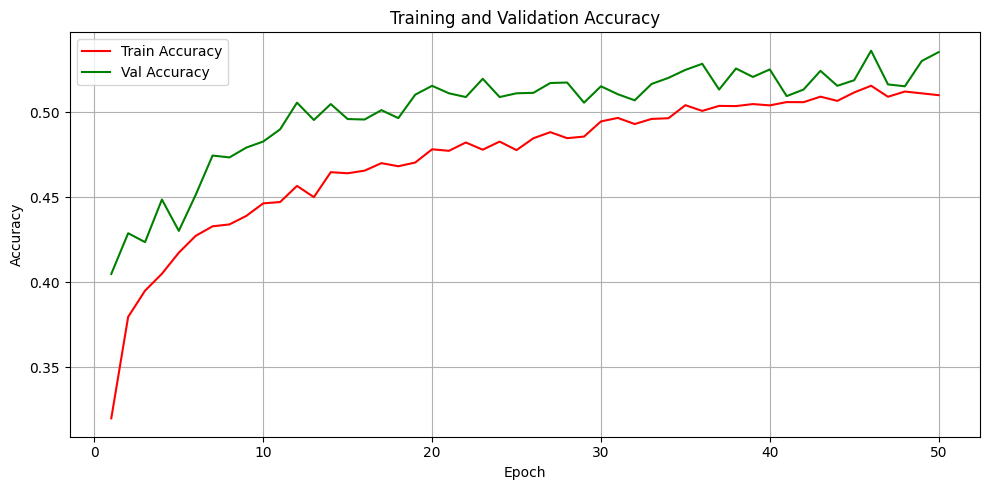

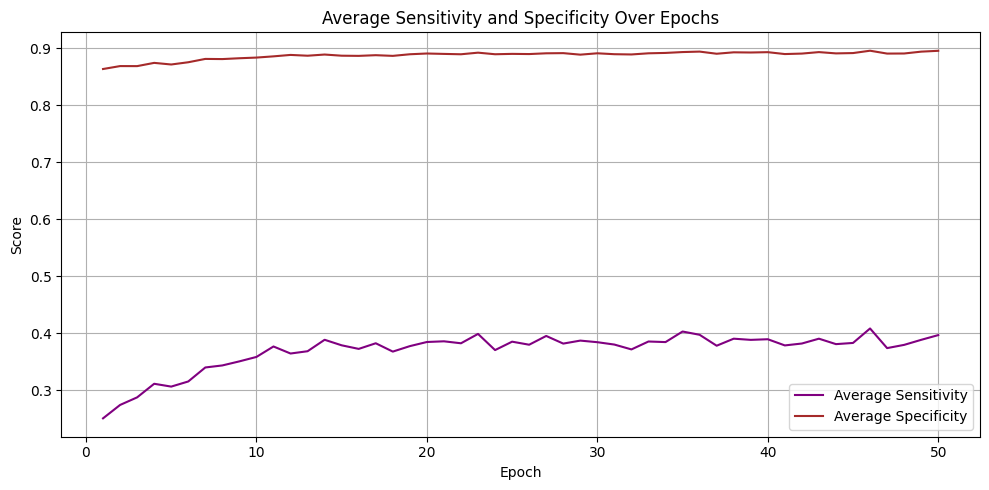

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists of arrays to numpy arrays for easier indexing
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

epochs = sensitivities_arr.shape[0]
n_classes = sensitivities_arr.shape[1]
epochs_range = range(1, epochs + 1)

# Plot sensitivity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, sensitivities_arr[:, i], label=f"Class {i} Sensitivity")
plt.xlabel("Epoch")
plt.ylabel("Sensitivity")
plt.title("Per-class Sensitivity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot specificity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, specificities_arr[:, i], label=f"Class {i} Specificity")
plt.xlabel("Epoch")
plt.ylabel("Specificity")
plt.title("Per-class Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt

epochs = len(train_losses)
epochs_range = range(1, epochs + 1)
n_classes = sensitivities_arr.shape[1]

# Convert lists of arrays to numpy arrays (if not already)
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

# 1) Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label="Train Loss", color="blue")
plt.plot(epochs_range, val_losses, label="Val Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy", color="red")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Plot average sensitivity and specificity across classes
avg_sensitivity = np.mean(sensitivities_arr, axis=1)
avg_specificity = np.mean(specificities_arr, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, avg_sensitivity, label="Average Sensitivity", color="purple")
plt.plot(epochs_range, avg_specificity, label="Average Specificity", color="brown")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Average Sensitivity and Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Test Results - Multiclass (50 epochs + oversampling)

In [46]:
print("Evaluating model on test dataset...")
(
    test_loss,
    test_acc,
    test_f1,
    test_sensitivity,
    test_specificity,
    test_sensitivity_arr,
    test_specificity_arr,
    test_auc
) = evaluate_multiclass(model, test_loader, criterion, device)

print(f"\n{'='*60}")
print("MULTICLASS TEST RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Mean Sensitivity: {test_sensitivity:.4f}")
print(f"Mean Specificity: {test_specificity:.4f}")
if test_auc is not None:
    print(f"Test AUC-ROC (macro avg): {test_auc:.4f}")
else:
    print("Test AUC-ROC: N/A")
print(f"{'-'*60}")
print("Per-Class Sensitivity:")
for i, s in enumerate(test_sensitivity_arr):
    print(f"  Class {i}: {s:.4f}")
print("Per-Class Specificity:")
for i, s in enumerate(test_specificity_arr):
    print(f"  Class {i}: {s:.4f}")
print(f"{'='*60}")

Evaluating model on test dataset...

MULTICLASS TEST RESULTS
Test Loss: 1.1324
Test Accuracy: 0.5294
Test F1-Score: 0.5083
Mean Sensitivity: 0.3968
Mean Specificity: 0.8941
Test AUC-ROC (macro avg): 0.8434
------------------------------------------------------------
Per-Class Sensitivity:
  Class 0: 0.6830
  Class 1: 0.6679
  Class 2: 0.4603
  Class 3: 0.0734
  Class 4: 0.1062
  Class 5: 0.3898
Per-Class Specificity:
  Class 0: 0.7901
  Class 1: 0.7957
  Class 2: 0.8222
  Class 3: 0.9972
  Class 4: 0.9836
  Class 5: 0.9756


## Set-up Class Weights

In [51]:
import numpy as np
import torch
from collections import Counter

def compute_class_weight(strategy='balanced', classes=None, y=None):
    """
    Compute class weights for imbalanced datasets.
    
    Parameters:
    -----------
    strategy : str, default='balanced'
        The strategy to compute class weights. Options:
        - 'balanced': n_samples / (n_classes * np.bincount(y))
        - 'uniform': all weights = 1.0
    classes : array-like, optional
        Unique classes in the dataset. If None, inferred from y.
    y : array-like
        Target values (class labels).
        
    Returns:
    --------
    class_weights : numpy array
        Array of weights for each class, ordered by class label.
    """
    
    if classes is None:
        classes = np.unique(y)
    
    if strategy == 'uniform':
        return np.ones(len(classes), dtype=np.float64)
    
    elif strategy == 'balanced':
        # Count occurrences of each class
        class_counts = Counter(y)
        n_samples = len(y)
        n_classes = len(classes)
        
        # Compute balanced weights: n_samples / (n_classes * count_for_class)
        weights = []
        for class_label in sorted(classes):
            count = class_counts[class_label]
            weight = n_samples / (n_classes * count)
            weights.append(weight)
            
        return np.array(weights, dtype=np.float64)
    
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

In [52]:
y_train = train_simple_df['class_label'].values
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

Class weights: tensor([0.6912, 0.5766, 0.5660, 5.5550, 2.0745, 2.5658], device='cuda:0')


## Initialise Model

In [53]:
model = ClassificationModel(num_features=len(feature_cols), num_classes=len(np.unique(y_train))).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

# Use class weights in loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Train - Multiclass (50 epochs + class weighting)

In [54]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
f1_scores = []
sensitivities = []
specificities = []
sensitivities_arr = []  
specificities_arr = []
auc_scores = []


epochs=50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, f1, sensitivity, specificity, sensitivity_arr, specificity_arr, auc = evaluate_multiclass(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    sensitivities_arr.append(sensitivity_arr)
    specificities_arr.append(specificity_arr)
    auc_scores.append(auc)


    print(
        f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}"
    )
    for i, (sens, spec) in enumerate(zip(sensitivity_arr, specificity_arr)):
        print(f"  Class {i}: Sensitivity: {sens:.4f}, Specificity: {spec:.4f}")

Epoch 01 | Train Loss: 1.9831 | Val Loss: 1.6214 | Train Acc: 0.2306 | Val Acc: 0.3120 | F1: 0.3116 | Sensitivity: 0.3312 | Specificity: 0.8581
  Class 0: Sensitivity: 0.4835, Specificity: 0.7121
  Class 1: Sensitivity: 0.3501, Specificity: 0.8348
  Class 2: Sensitivity: 0.1495, Specificity: 0.9018
  Class 3: Sensitivity: 0.5505, Specificity: 0.8775
  Class 4: Sensitivity: 0.2671, Specificity: 0.8570
  Class 5: Sensitivity: 0.1864, Specificity: 0.9653
Epoch 02 | Train Loss: 1.7595 | Val Loss: 1.5441 | Train Acc: 0.2709 | Val Acc: 0.3730 | F1: 0.3640 | Sensitivity: 0.3911 | Specificity: 0.8690
  Class 0: Sensitivity: 0.5804, Specificity: 0.7154
  Class 1: Sensitivity: 0.4301, Specificity: 0.8289
  Class 2: Sensitivity: 0.1692, Specificity: 0.9099
  Class 3: Sensitivity: 0.5963, Specificity: 0.9161
  Class 4: Sensitivity: 0.2568, Specificity: 0.9013
  Class 5: Sensitivity: 0.3136, Specificity: 0.9426
Epoch 03 | Train Loss: 1.6837 | Val Loss: 1.5178 | Train Acc: 0.2959 | Val Acc: 0.4083 |

Epoch 19 | Train Loss: 1.3985 | Val Loss: 1.3226 | Train Acc: 0.3973 | Val Acc: 0.4525 | F1: 0.4241 | Sensitivity: 0.4681 | Specificity: 0.8856
  Class 0: Sensitivity: 0.8141, Specificity: 0.6719
  Class 1: Sensitivity: 0.4615, Specificity: 0.8731
  Class 2: Sensitivity: 0.1505, Specificity: 0.9637
  Class 3: Sensitivity: 0.5046, Specificity: 0.9475
  Class 4: Sensitivity: 0.4075, Specificity: 0.9055
  Class 5: Sensitivity: 0.4703, Specificity: 0.9520
Epoch 20 | Train Loss: 1.3987 | Val Loss: 1.3190 | Train Acc: 0.4042 | Val Acc: 0.4459 | F1: 0.4171 | Sensitivity: 0.4688 | Specificity: 0.8846
  Class 0: Sensitivity: 0.8176, Specificity: 0.6581
  Class 1: Sensitivity: 0.4481, Specificity: 0.8866
  Class 2: Sensitivity: 0.1449, Specificity: 0.9626
  Class 3: Sensitivity: 0.5963, Specificity: 0.9402
  Class 4: Sensitivity: 0.4075, Specificity: 0.9058
  Class 5: Sensitivity: 0.3983, Specificity: 0.9541
Epoch 21 | Train Loss: 1.3934 | Val Loss: 1.3230 | Train Acc: 0.3988 | Val Acc: 0.4713 |

Epoch 37 | Train Loss: 1.3099 | Val Loss: 1.3028 | Train Acc: 0.4256 | Val Acc: 0.4776 | F1: 0.4534 | Sensitivity: 0.4787 | Specificity: 0.8898
  Class 0: Sensitivity: 0.7719, Specificity: 0.7103
  Class 1: Sensitivity: 0.5671, Specificity: 0.8471
  Class 2: Sensitivity: 0.1766, Specificity: 0.9520
  Class 3: Sensitivity: 0.5413, Specificity: 0.9487
  Class 4: Sensitivity: 0.4041, Specificity: 0.9174
  Class 5: Sensitivity: 0.4110, Specificity: 0.9632
Epoch 38 | Train Loss: 1.3149 | Val Loss: 1.2736 | Train Acc: 0.4242 | Val Acc: 0.4836 | F1: 0.4665 | Sensitivity: 0.4983 | Specificity: 0.8918
  Class 0: Sensitivity: 0.7446, Specificity: 0.7520
  Class 1: Sensitivity: 0.5652, Specificity: 0.8448
  Class 2: Sensitivity: 0.2075, Specificity: 0.9423
  Class 3: Sensitivity: 0.6330, Specificity: 0.9353
  Class 4: Sensitivity: 0.3904, Specificity: 0.9189
  Class 5: Sensitivity: 0.4492, Specificity: 0.9573
Epoch 39 | Train Loss: 1.3053 | Val Loss: 1.3068 | Train Acc: 0.4301 | Val Acc: 0.4806 |

## Plot Results - Multiclass (50 epochs + class weighting)

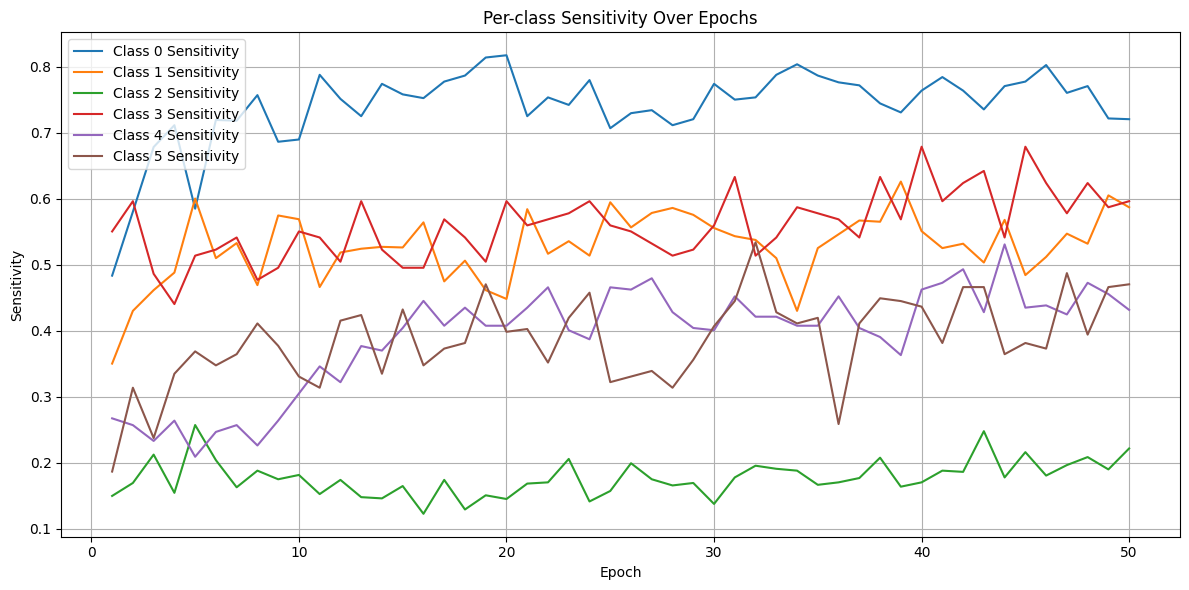

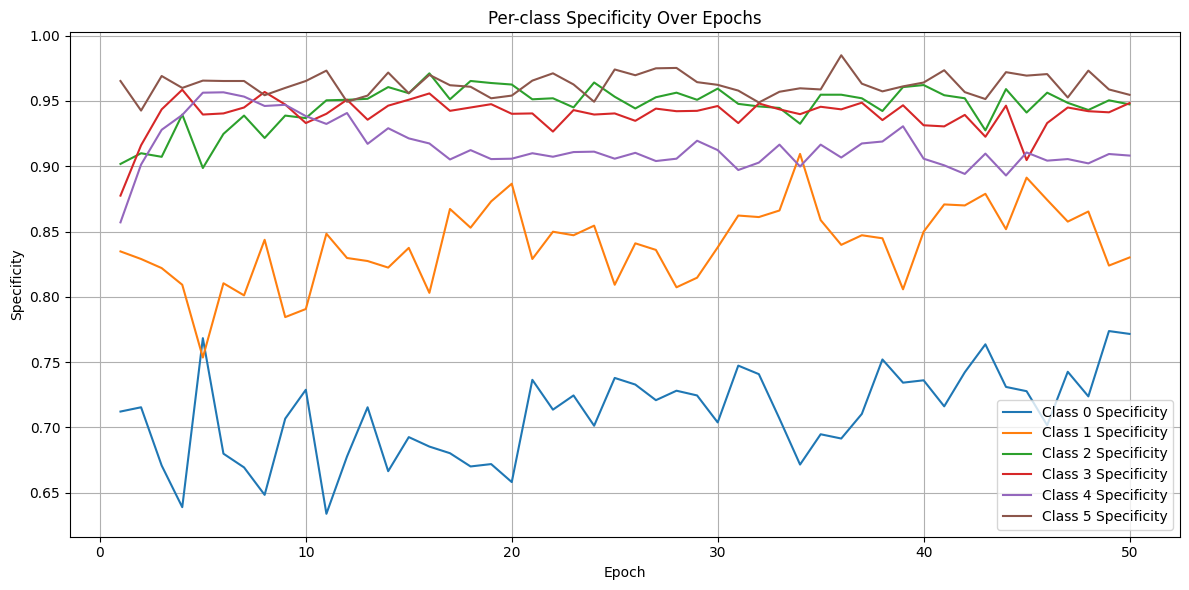

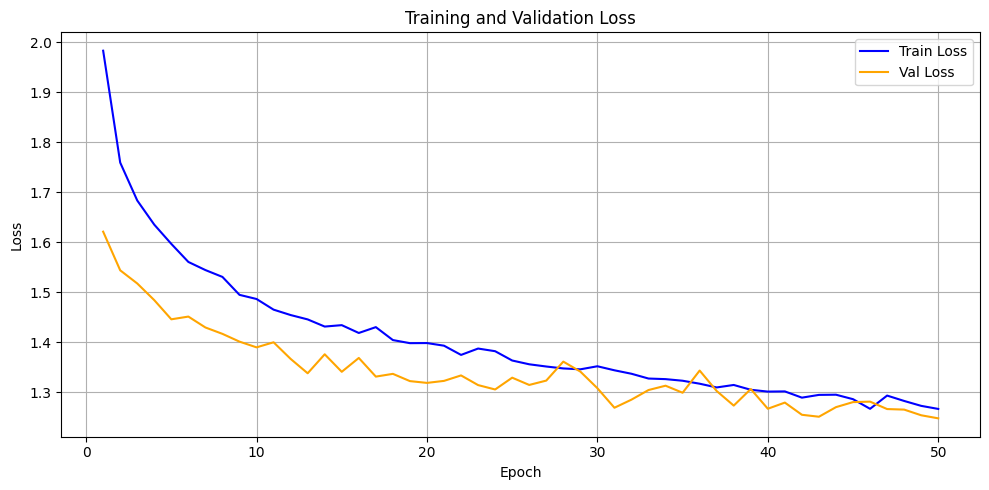

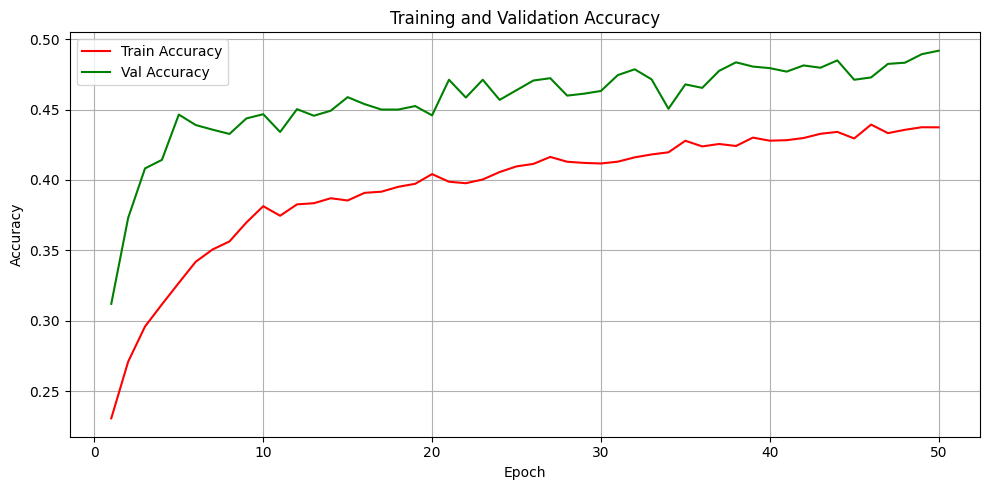

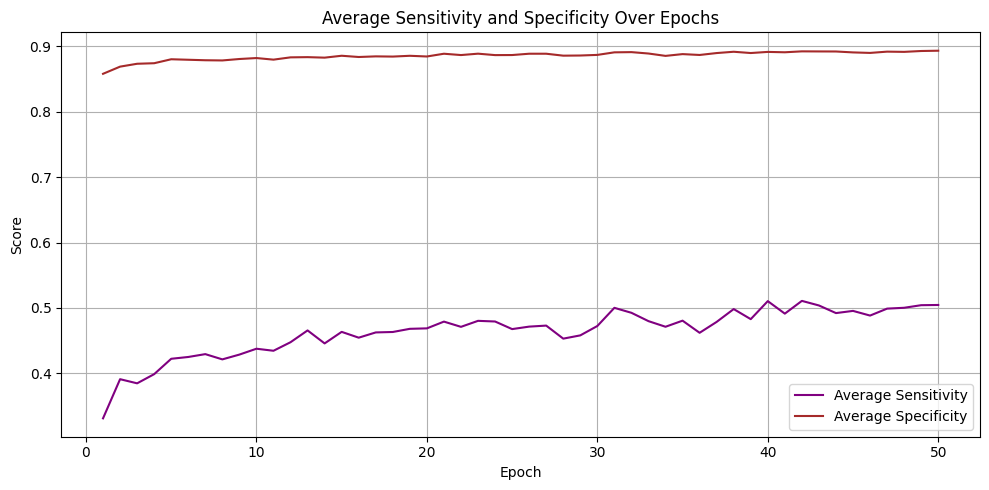

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists of arrays to numpy arrays for easier indexing
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

epochs = sensitivities_arr.shape[0]
n_classes = sensitivities_arr.shape[1]
epochs_range = range(1, epochs + 1)

# Plot sensitivity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, sensitivities_arr[:, i], label=f"Class {i} Sensitivity")
plt.xlabel("Epoch")
plt.ylabel("Sensitivity")
plt.title("Per-class Sensitivity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot specificity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, specificities_arr[:, i], label=f"Class {i} Specificity")
plt.xlabel("Epoch")
plt.ylabel("Specificity")
plt.title("Per-class Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt

epochs = len(train_losses)
epochs_range = range(1, epochs + 1)
n_classes = sensitivities_arr.shape[1]

# Convert lists of arrays to numpy arrays (if not already)
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

# 1) Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label="Train Loss", color="blue")
plt.plot(epochs_range, val_losses, label="Val Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy", color="red")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Plot average sensitivity and specificity across classes
avg_sensitivity = np.mean(sensitivities_arr, axis=1)
avg_specificity = np.mean(specificities_arr, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, avg_sensitivity, label="Average Sensitivity", color="purple")
plt.plot(epochs_range, avg_specificity, label="Average Specificity", color="brown")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Average Sensitivity and Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Test Results - Multiclass (50 epochs + class weighting)

In [56]:
print("Evaluating model on test dataset...")
(
    test_loss,
    test_acc,
    test_f1,
    test_sensitivity,
    test_specificity,
    test_sensitivity_arr,
    test_specificity_arr,
    test_auc
) = evaluate_multiclass(model, test_loader, criterion, device)

print(f"\n{'='*60}")
print("MULTICLASS TEST RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Mean Sensitivity: {test_sensitivity:.4f}")
print(f"Mean Specificity: {test_specificity:.4f}")
if test_auc is not None:
    print(f"Test AUC-ROC (macro avg): {test_auc:.4f}")
else:
    print("Test AUC-ROC: N/A")
print(f"{'-'*60}")
print("Per-Class Sensitivity:")
for i, s in enumerate(test_sensitivity_arr):
    print(f"  Class {i}: {s:.4f}")
print("Per-Class Specificity:")
for i, s in enumerate(test_specificity_arr):
    print(f"  Class {i}: {s:.4f}")
print(f"{'='*60}")

Evaluating model on test dataset...

MULTICLASS TEST RESULTS
Test Loss: 1.2516
Test Accuracy: 0.4843
Test F1-Score: 0.4708
Mean Sensitivity: 0.5049
Mean Specificity: 0.8918
Test AUC-ROC (macro avg): 0.8369
------------------------------------------------------------
Per-Class Sensitivity:
  Class 0: 0.7013
  Class 1: 0.5766
  Class 2: 0.2241
  Class 3: 0.6514
  Class 4: 0.3973
  Class 5: 0.4788
Per-Class Specificity:
  Class 0: 0.7691
  Class 1: 0.8244
  Class 2: 0.9462
  Class 3: 0.9325
  Class 4: 0.9181
  Class 5: 0.9606


## Set-up Focal Loss

In [63]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # tensor of shape [num_classes] or None
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, inputs, targets):
        logpt = -self.ce(inputs, targets)
        pt = torch.exp(logpt)
        focal_loss = -((1 - pt) ** self.gamma) * logpt

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

## Extract Features

In [64]:
feature_cols = [col for col in mwr_df_simple.columns if col.endswith('int') or col.endswith('sk')]
mwr_df_simple['features'] = mwr_df_simple[feature_cols].values.tolist()

mwr_df_simple['class_label'] = mwr_df_simple['r:Th'].astype(int)

In [65]:
train_simple_df, temp_simple_df = train_test_split(
    mwr_df_simple, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df_simple['r:Th']
)

val_simple_df, test_simple_df = train_test_split(
    temp_simple_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_simple_df['r:Th']
)

## Initialise Model

In [66]:
num_classes = len(np.unique(y_train))
num_features = len(feature_cols)

model = ClassificationModel(num_features=num_features, num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

# Choose loss here: CrossEntropyLoss or FocalLoss

use_focal_loss = True  # Set False to use normal CrossEntropyLoss

if use_focal_loss:
    criterion = FocalLoss(alpha=class_weights, gamma=2, reduction='mean')
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights)

## Train - Multiclass (50 epochs + focal loss)

In [67]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
f1_scores = []
sensitivities = []
specificities = []
sensitivities_arr = []  
specificities_arr = []
auc_scores = []


epochs=50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, f1, sensitivity, specificity, sensitivity_arr, specificity_arr, auc = evaluate_multiclass(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    sensitivities_arr.append(sensitivity_arr)
    specificities_arr.append(specificity_arr)
    auc_scores.append(auc)


    print(
        f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {f1:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}"
    )
    for i, (sens, spec) in enumerate(zip(sensitivity_arr, specificity_arr)):
        print(f"  Class {i}: Sensitivity: {sens:.4f}, Specificity: {spec:.4f}")

Epoch 01 | Train Loss: 1.4718 | Val Loss: 1.1161 | Train Acc: 0.2015 | Val Acc: 0.3194 | F1: 0.3001 | Sensitivity: 0.3506 | Specificity: 0.8621
  Class 0: Sensitivity: 0.6021, Specificity: 0.6766
  Class 1: Sensitivity: 0.3264, Specificity: 0.8684
  Class 2: Sensitivity: 0.0766, Specificity: 0.9649
  Class 3: Sensitivity: 0.5046, Specificity: 0.9058
  Class 4: Sensitivity: 0.2295, Specificity: 0.8723
  Class 5: Sensitivity: 0.3644, Specificity: 0.8844
Epoch 02 | Train Loss: 1.2421 | Val Loss: 1.0536 | Train Acc: 0.2393 | Val Acc: 0.3593 | F1: 0.3220 | Sensitivity: 0.3960 | Specificity: 0.8678
  Class 0: Sensitivity: 0.6511, Specificity: 0.6461
  Class 1: Sensitivity: 0.4206, Specificity: 0.8464
  Class 2: Sensitivity: 0.0505, Specificity: 0.9758
  Class 3: Sensitivity: 0.5505, Specificity: 0.9223
  Class 4: Sensitivity: 0.2329, Specificity: 0.9103
  Class 5: Sensitivity: 0.4703, Specificity: 0.9059
Epoch 03 | Train Loss: 1.1661 | Val Loss: 1.0208 | Train Acc: 0.2522 | Val Acc: 0.3777 |

Epoch 19 | Train Loss: 0.9127 | Val Loss: 0.8295 | Train Acc: 0.3388 | Val Acc: 0.4149 | F1: 0.3669 | Sensitivity: 0.4712 | Specificity: 0.8795
  Class 0: Sensitivity: 0.8210, Specificity: 0.6222
  Class 1: Sensitivity: 0.3939, Specificity: 0.9052
  Class 2: Sensitivity: 0.0598, Specificity: 0.9832
  Class 3: Sensitivity: 0.6330, Specificity: 0.9322
  Class 4: Sensitivity: 0.4281, Specificity: 0.8917
  Class 5: Sensitivity: 0.4915, Specificity: 0.9423
Epoch 20 | Train Loss: 0.9019 | Val Loss: 0.8374 | Train Acc: 0.3422 | Val Acc: 0.4223 | F1: 0.3725 | Sensitivity: 0.4756 | Specificity: 0.8806
  Class 0: Sensitivity: 0.8187, Specificity: 0.6182
  Class 1: Sensitivity: 0.4244, Specificity: 0.8974
  Class 2: Sensitivity: 0.0523, Specificity: 0.9867
  Class 3: Sensitivity: 0.6239, Specificity: 0.9248
  Class 4: Sensitivity: 0.4726, Specificity: 0.9010
  Class 5: Sensitivity: 0.4619, Specificity: 0.9553
Epoch 21 | Train Loss: 0.8927 | Val Loss: 0.8282 | Train Acc: 0.3516 | Val Acc: 0.4234 |

Epoch 37 | Train Loss: 0.8245 | Val Loss: 0.7720 | Train Acc: 0.3593 | Val Acc: 0.4399 | F1: 0.4043 | Sensitivity: 0.5030 | Specificity: 0.8853
  Class 0: Sensitivity: 0.7434, Specificity: 0.7110
  Class 1: Sensitivity: 0.4891, Specificity: 0.8750
  Class 2: Sensitivity: 0.0879, Specificity: 0.9743
  Class 3: Sensitivity: 0.6881, Specificity: 0.9158
  Class 4: Sensitivity: 0.4589, Specificity: 0.8980
  Class 5: Sensitivity: 0.5508, Specificity: 0.9376
Epoch 38 | Train Loss: 0.8129 | Val Loss: 0.7789 | Train Acc: 0.3652 | Val Acc: 0.4410 | F1: 0.4094 | Sensitivity: 0.5036 | Specificity: 0.8853
  Class 0: Sensitivity: 0.7161, Specificity: 0.7219
  Class 1: Sensitivity: 0.5033, Specificity: 0.8657
  Class 2: Sensitivity: 0.0963, Specificity: 0.9727
  Class 3: Sensitivity: 0.7156, Specificity: 0.9129
  Class 4: Sensitivity: 0.5582, Specificity: 0.8717
  Class 5: Sensitivity: 0.4322, Specificity: 0.9670
Epoch 39 | Train Loss: 0.8142 | Val Loss: 0.7641 | Train Acc: 0.3691 | Val Acc: 0.4443 |

## Plot Results - Multiclass (50 epochs + focal loss)

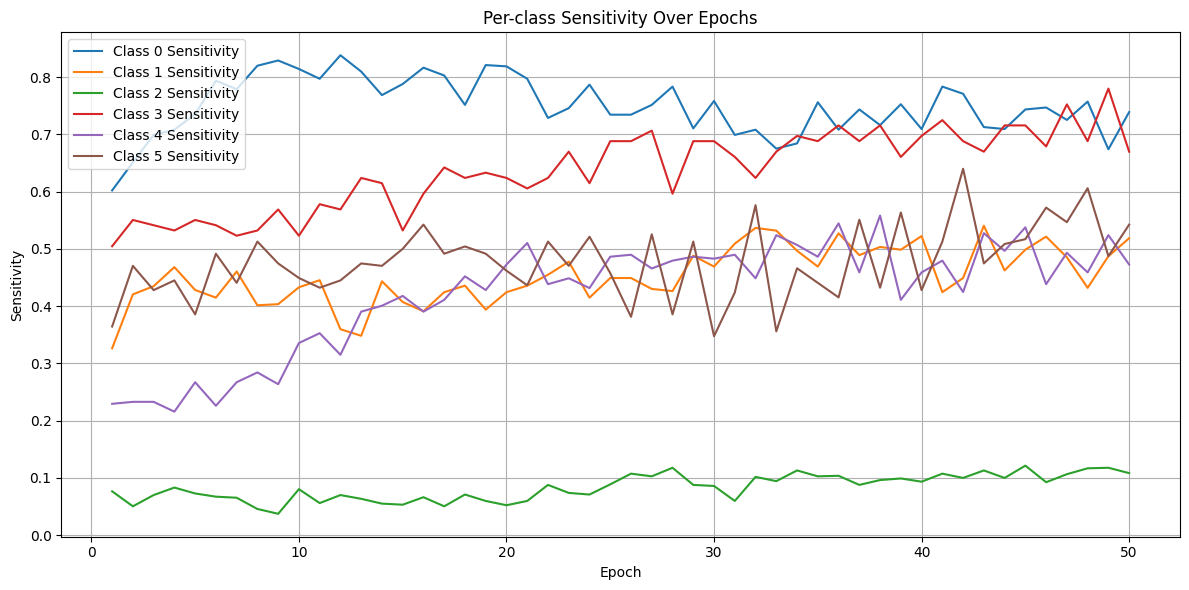

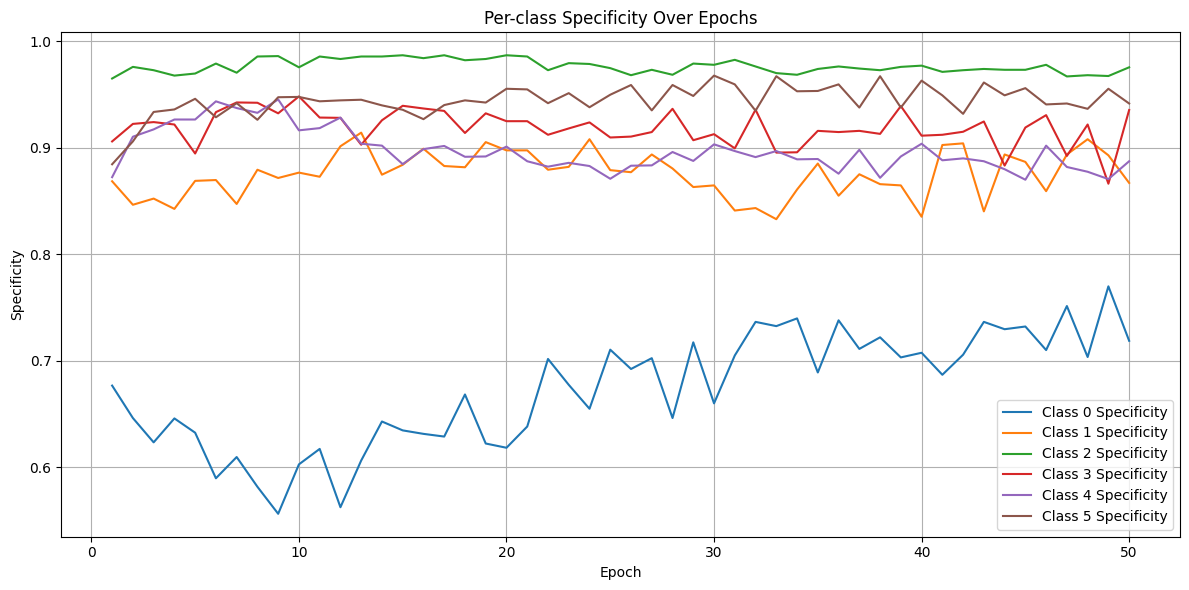

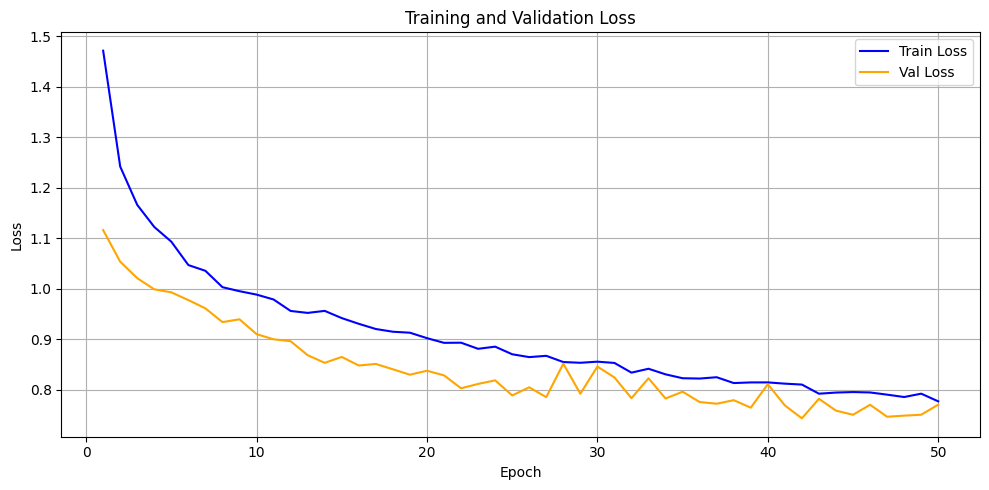

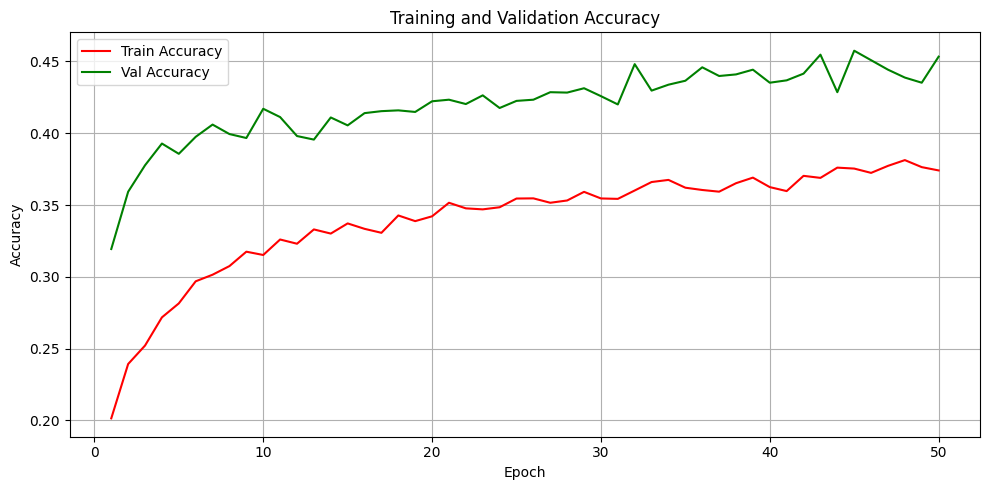

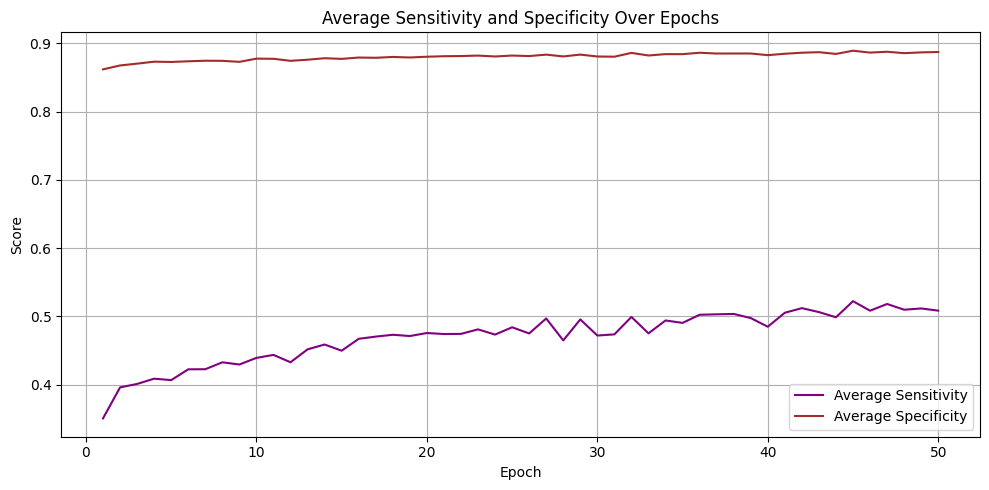

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists of arrays to numpy arrays for easier indexing
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

epochs = sensitivities_arr.shape[0]
n_classes = sensitivities_arr.shape[1]
epochs_range = range(1, epochs + 1)

# Plot sensitivity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, sensitivities_arr[:, i], label=f"Class {i} Sensitivity")
plt.xlabel("Epoch")
plt.ylabel("Sensitivity")
plt.title("Per-class Sensitivity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot specificity per class
plt.figure(figsize=(12, 6))
for i in range(n_classes):
    plt.plot(epochs_range, specificities_arr[:, i], label=f"Class {i} Specificity")
plt.xlabel("Epoch")
plt.ylabel("Specificity")
plt.title("Per-class Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt

epochs = len(train_losses)
epochs_range = range(1, epochs + 1)
n_classes = sensitivities_arr.shape[1]

# Convert lists of arrays to numpy arrays (if not already)
sensitivities_arr = np.array(sensitivities_arr)  # shape: (epochs, n_classes)
specificities_arr = np.array(specificities_arr)  # shape: (epochs, n_classes)

# 1) Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label="Train Loss", color="blue")
plt.plot(epochs_range, val_losses, label="Val Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy", color="red")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Plot average sensitivity and specificity across classes
avg_sensitivity = np.mean(sensitivities_arr, axis=1)
avg_specificity = np.mean(specificities_arr, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, avg_sensitivity, label="Average Sensitivity", color="purple")
plt.plot(epochs_range, avg_specificity, label="Average Specificity", color="brown")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Average Sensitivity and Specificity Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Test Results - Multiclass (50 epochs + focal loss)

In [70]:
print("Evaluating model on test dataset...")
(
    test_loss,
    test_acc,
    test_f1,
    test_sensitivity,
    test_specificity,
    test_sensitivity_arr,
    test_specificity_arr,
    test_auc
) = evaluate_multiclass(model, test_loader, criterion, device)

print(f"\n{'='*60}")
print("MULTICLASS TEST RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Mean Sensitivity: {test_sensitivity:.4f}")
print(f"Mean Specificity: {test_specificity:.4f}")
if test_auc is not None:
    print(f"Test AUC-ROC (macro avg): {test_auc:.4f}")
else:
    print("Test AUC-ROC: N/A")
print(f"{'-'*60}")
print("Per-Class Sensitivity:")
for i, s in enumerate(test_sensitivity_arr):
    print(f"  Class {i}: {s:.4f}")
print("Per-Class Specificity:")
for i, s in enumerate(test_specificity_arr):
    print(f"  Class {i}: {s:.4f}")
print(f"{'='*60}")

Evaluating model on test dataset...

MULTICLASS TEST RESULTS
Test Loss: 0.7944
Test Accuracy: 0.4398
Test F1-Score: 0.4084
Mean Sensitivity: 0.4933
Mean Specificity: 0.8845
Test AUC-ROC (macro avg): 0.8172
------------------------------------------------------------
Per-Class Sensitivity:
  Class 0: 0.7195
  Class 1: 0.5005
  Class 2: 0.1055
  Class 3: 0.6514
  Class 4: 0.4658
  Class 5: 0.5169
Per-Class Specificity:
  Class 0: 0.7122
  Class 1: 0.8549
  Class 2: 0.9762
  Class 3: 0.9246
  Class 4: 0.8882
  Class 5: 0.9509
